This is a parallel notebook to _process_HE_data_ script intended for testing the different steps involved in the data processing.

In [1]:
import sys
sys.path.append('/lhome/ific/c/ccortesp/Analysis/')

from libs import crudo

import argparse
import csv
import glob
from invisible_cities.core.core_functions import in_range
from invisible_cities.reco.corrections import apply_all_correction, read_maps
from invisible_cities.types.symbols import NormMethod, NormStrategy
from joblib import delayed, Parallel
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from scipy.interpolate import griddata
from scipy.interpolate import interp1d
from scipy.spatial.distance import cdist
from sklearn.neighbors import BallTree
from sklearn.neighbors import NearestNeighbors
from sklearn.exceptions import NotFittedError
from typing import Callable, List, Tuple

# Styling Plot
crudo.pt.ccortesp_plot_style()

%matplotlib inline
%load_ext autoreload
%autoreload 2

# Configuration

In [2]:
# OUTPUT FILENAME TAG
VERSION_TAG = 'LPR_p2'

# DIRECTORIES, PATHS & FILES
DATA_DIR   = '/lhome/ific/c/ccortesp/Analysis/NEXT-100/Th_analysis/h5/runs/'
ICAROS_DIR = '/lhome/ific/c/ccortesp/Analysis/NEXT-100/Th_analysis/h5/'
OUTPUT_DIR = '/lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Th_analysis/h5/runs/'

SUMMARY_FILENAME = 'summary_' + VERSION_TAG + '_processed.csv'
SUMMARY_PATH = os.path.join('/lhome/ific/c/ccortesp/Analysis/NEXT-100/Th_analysis/txt/summaries/', SUMMARY_FILENAME)

# KEYS
DORO_KEY = 'DST/Events'
SOPH_KEY = 'RECO/Events'

# COLUMNS TO USE
DORO_COLUMNS = ['event', 'time', 'nS1', 'nS2', 'S1w', 'S1h', 'S1e', 'S1t', 'S2w', 'S2h', 'S2e', 'S2q', 'S2t', 'DT', 'X', 'Y', 'Z']
SOPH_COLUMNS = ['event', 'time', 'npeak', 'X', 'Y', 'Z', 'Q', 'E']
FINAL_SOPH_COLUMNS = ['event', 'time', 'npeak', 'X', 'Y', 'DT', 'Z', 'E_hit_mev', 'cluster']

EVENT_LEVEL_COLS = ['nS1', 'nS2', 'old_n_hits']

# CUTFLOW
CUT_NAMES = ['IC', 'Z_Positive', 'S1_Cut', 'Clean_Events']

# ---------------------
# PROCESSING PARAMETERS
# ---------------------
V_DRIFT = 0.865     # Drift velocity in [mm/μs]

# --- S1 Signal Cuts ---
# Po-like events are filtered using: S1h >= m * S1e + b
M_NOPOLIKE = 0.17
B_NOPOLIKE = -56

# --- S1e Correction ---
# Values from Radon analysis: S1e = m * DT + b
DT_CATH = 1350               # Cathode temporal position in [μs]
CV_FIT  = [0.57, 796.53]     # Fit values from S1e vs DT plot

# --- Hits Clusterizer ---
CLUSTERING_PARAMS = dict(eps = 1.8, min_samples = 5, scale_xy = 15.55, scale_z = 4.0)
CLUSTER_FUNCTION = crudo.tf.hits_clusterizer(CLUSTERING_PARAMS)

# -----------------------------
# ALPHA/ELECTRON DISCRIMINATION
# -----------------------------
SIZE_THRESHOLD = 2e3            # in [# of hits]
S1_ENERGY_THRESHOLD = 900      # in [PE]

# ----------------
# DETECTOR REGIONS
# ----------------
# Geometric boundaries for event classification.
Z_LOW = 40          # in [mm]
Z_UP  = 1147        # in [mm]
R_UP  = 451.65      # in [mm]

# ---------
# SELECTION
# ----------
# --- High Energy Scale Correction ---
# Values from Thorium analysis
M_HE_SCALE = 4.80e-06
B_HE_SCALE = 0.0094

# --- Trigger 2 Efficiency Cut ---
# Events with event-level energy below this are removed to account for trigger efficiency
TRG2_THRESHOLD = 0.5   # in [MeV]

# Preliminary

In [3]:
# --- Parse Arguments
RUN_NUMBER = 15589
LDC_NUMBER = 1
N_FILES = 500
KR_CITY = 'zemrude'

In [4]:
# Construct specific input/output directories based on run and LDC
INPUT_DIR = os.path.join(DATA_DIR, f"{RUN_NUMBER}", f"ldc{LDC_NUMBER}")
if not os.path.isdir(INPUT_DIR):
    print(f"   Error: Input directory '{INPUT_DIR}' does not exist.", file=sys.stderr)
    sys.exit(1)
file_list = sorted(glob.glob(os.path.join(INPUT_DIR, "*.h5")))
if not file_list:
    print(f"   Error: No .h5 files found in '{INPUT_DIR}'.", file=sys.stderr)
    sys.exit(1)

# Determine the number of files to process
max_files_to_process = None     # None means NO limit
if N_FILES != 'all':
    try:
        max_files_to_process = int(N_FILES)
        if max_files_to_process <= 0:
            print(f"   Error: Number of files must be a positive integer, not '{N_FILES}'.", file=sys.stderr)
            sys.exit(1)
    except ValueError:
        print(f"   Error: Invalid value for n_files. Expected a number or 'all', but got '{N_FILES}'.", file=sys.stderr)
        sys.exit(1)
files_to_process = file_list[:max_files_to_process] if max_files_to_process is not None else file_list

# Find the Kr map
kr_file = next((f 
                for f in os.listdir(ICAROS_DIR) 
                if (f'run_{RUN_NUMBER}' in f and
                    ((KR_CITY == 'icaros' and f.endswith('map.h5')) or 
                     (KR_CITY == 'zemrude' and f.endswith('zemrude.h5'))))), None)
if not kr_file:
    raise FileNotFoundError(f"   Error: NO Kr map file found for run {RUN_NUMBER} in {ICAROS_DIR}")
    sys.exit(1)
KR_PATH = os.path.join(ICAROS_DIR, kr_file)

os.makedirs(OUTPUT_DIR, exist_ok=True)
# Print configuration summary
print("\n----- Processing Configuration -----")
print(f"Run Number       : {RUN_NUMBER}")
print(f"LDC Number       : {LDC_NUMBER}")
print(f"Files to Process : {'All' if max_files_to_process is None else len(files_to_process)}")
print(f"Kr Map City      : {KR_CITY}")
print(f"Kr Map File      : {kr_file}")
print("------------------------------------")
print(f"Input Directory  : {INPUT_DIR}")
print(f"Output Directory : {OUTPUT_DIR}")
print("------------------------------------")


----- Processing Configuration -----
Run Number       : 15589
LDC Number       : 1
Files to Process : 500
Kr Map City      : zemrude
Kr Map File      : run_15589_zemrude.h5
------------------------------------
Input Directory  : /lhome/ific/c/ccortesp/Analysis/NEXT-100/Th_analysis/h5/runs/15589/ldc1
Output Directory : /lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Th_analysis/h5/runs/
------------------------------------


# Processing

In the processing script, we do not concatenate at first, cause' we use parallelization.

### Load Dorothea & Sophronia

In [5]:
# All dataframes to concatenate later
all_doros = []
all_sophs = []

for filepath in files_to_process[:-1]:
    # Here we use all the columns, but they can be reduced if needed
    file_doro = pd.read_hdf(filepath, key=DORO_KEY);    all_doros.append(file_doro)
    file_soph = pd.read_hdf(filepath, key=SOPH_KEY);    all_sophs.append(file_soph)

# Concatenate all dataframes
df_doro = pd.concat(all_doros, ignore_index=True)
df_soph = pd.concat(all_sophs, ignore_index=True)

# Compute Z in [mm]
df_soph.rename(columns={'Z': 'DT'}, inplace=True)
df_soph['Z'] = df_soph['DT'] * V_DRIFT
print(f"Run {RUN_NUMBER}: {df_soph['event'].nunique()} events loaded.")

Run 15589: 16512 events loaded.


### NO Spurious Hits

#### Clustering

We first cluster hits in each event using DBSCAN algorithm, tagging -1 hits as noisy hits.

In [7]:
df_clustered = CLUSTER_FUNCTION(df_soph)
df_clustered

,event,time,npeak,Xpeak,Ypeak,nsipm,X,Y,Xrms,Yrms,DT,Q,E,Qc,Ec,track_id,Ep,Z,cluster
0,8,1.751990e+09,37,58.275919,83.240983,1,-220.275,353.775,0.0,0.0,611.867625,7.227603,-4.504640,-1.0,-0.000027,-1,-1.0,529.265496,-1
1,8,1.751990e+09,37,58.275919,83.240983,1,212.125,-124.275,0.0,0.0,623.841500,7.801650,1.669304,-1.0,0.000009,-1,-1.0,539.622898,-1
2,8,1.751990e+09,37,58.275919,83.240983,1,351.075,260.975,0.0,0.0,632.354000,9.426950,307.351731,-1.0,0.001968,-1,-1.0,546.986210,0
3,8,1.751990e+09,37,58.275919,83.240983,1,366.625,245.425,0.0,0.0,632.354000,9.170438,298.988517,-1.0,0.001888,-1,-1.0,546.986210,0
4,8,1.751990e+09,37,58.275919,83.240983,1,273.325,-279.275,0.0,0.0,636.194875,7.454491,85.769688,-1.0,0.000470,-1,-1.0,550.308567,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15325661,366766,1.751998e+09,53,-24.131930,48.550230,1,-435.975,260.975,0.0,0.0,1587.496500,7.975994,215.631486,-1.0,NaN,-1,-1.0,1373.184472,-1
15325662,366766,1.751998e+09,53,-24.131930,48.550230,1,-235.825,245.925,0.0,0.0,1587.496500,7.753956,209.628681,-1.0,0.001206,-1,-1.0,1373.184472,1
15325663,366766,1.751998e+09,53,-24.131930,48.550230,1,-235.825,245.925,0.0,0.0,1590.878500,7.244573,35.076768,-1.0,0.000202,-1,-1.0,1376.109903,1
15325664,366766,1.751998e+09,53,-24.131930,48.550230,1,26.525,-448.825,0.0,0.0,1590.878500,10.834297,52.457495,-1.0,0.000354,-1,-1.0,1376.109903,-1


Event 155:


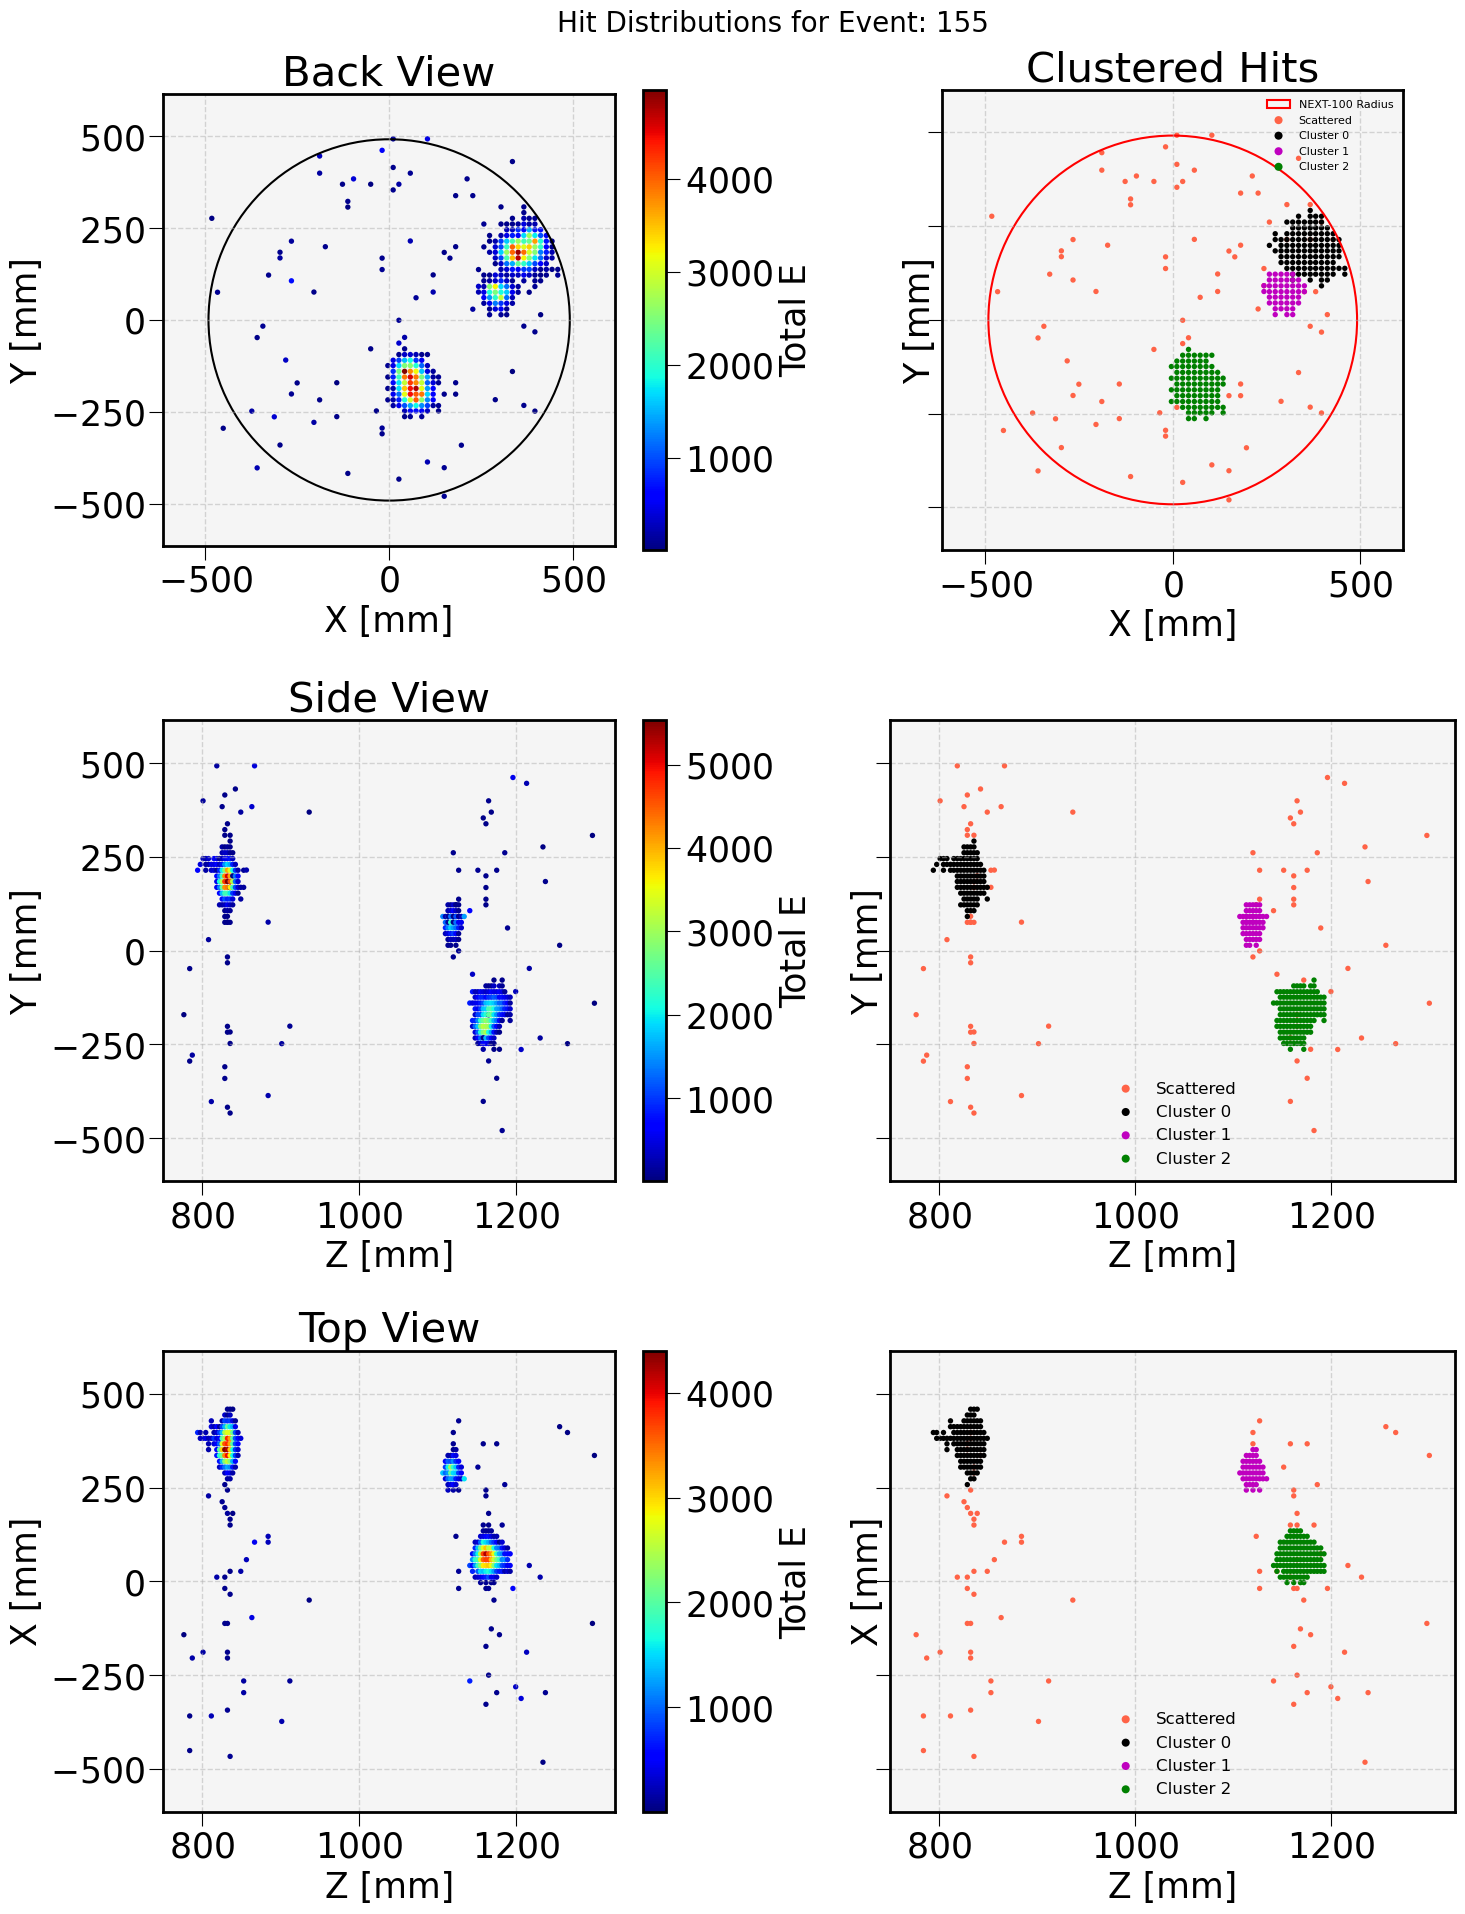

In [69]:
# Pick a random event from the clustered dataframe to visualize its hits
clust_evt_ids = df_clustered['event'].unique()

# Event information + visualization
evt_test_id = np.random.choice(clust_evt_ids)
print(f"Event {evt_test_id}:")
crudo.pt.display_event_cluster(df_clustered, variable='E', event=evt_test_id)

#### Energy re-distribution

In [52]:
clean_soph_df = crudo.tf.deal_spurious_hits(df_clustered, energy_column='E', output_column='E_hit_pe')
print(f"After cleaning spurious hits: {clean_soph_df['event'].nunique()} events.")

After cleaning spurious hits: 16512 events.


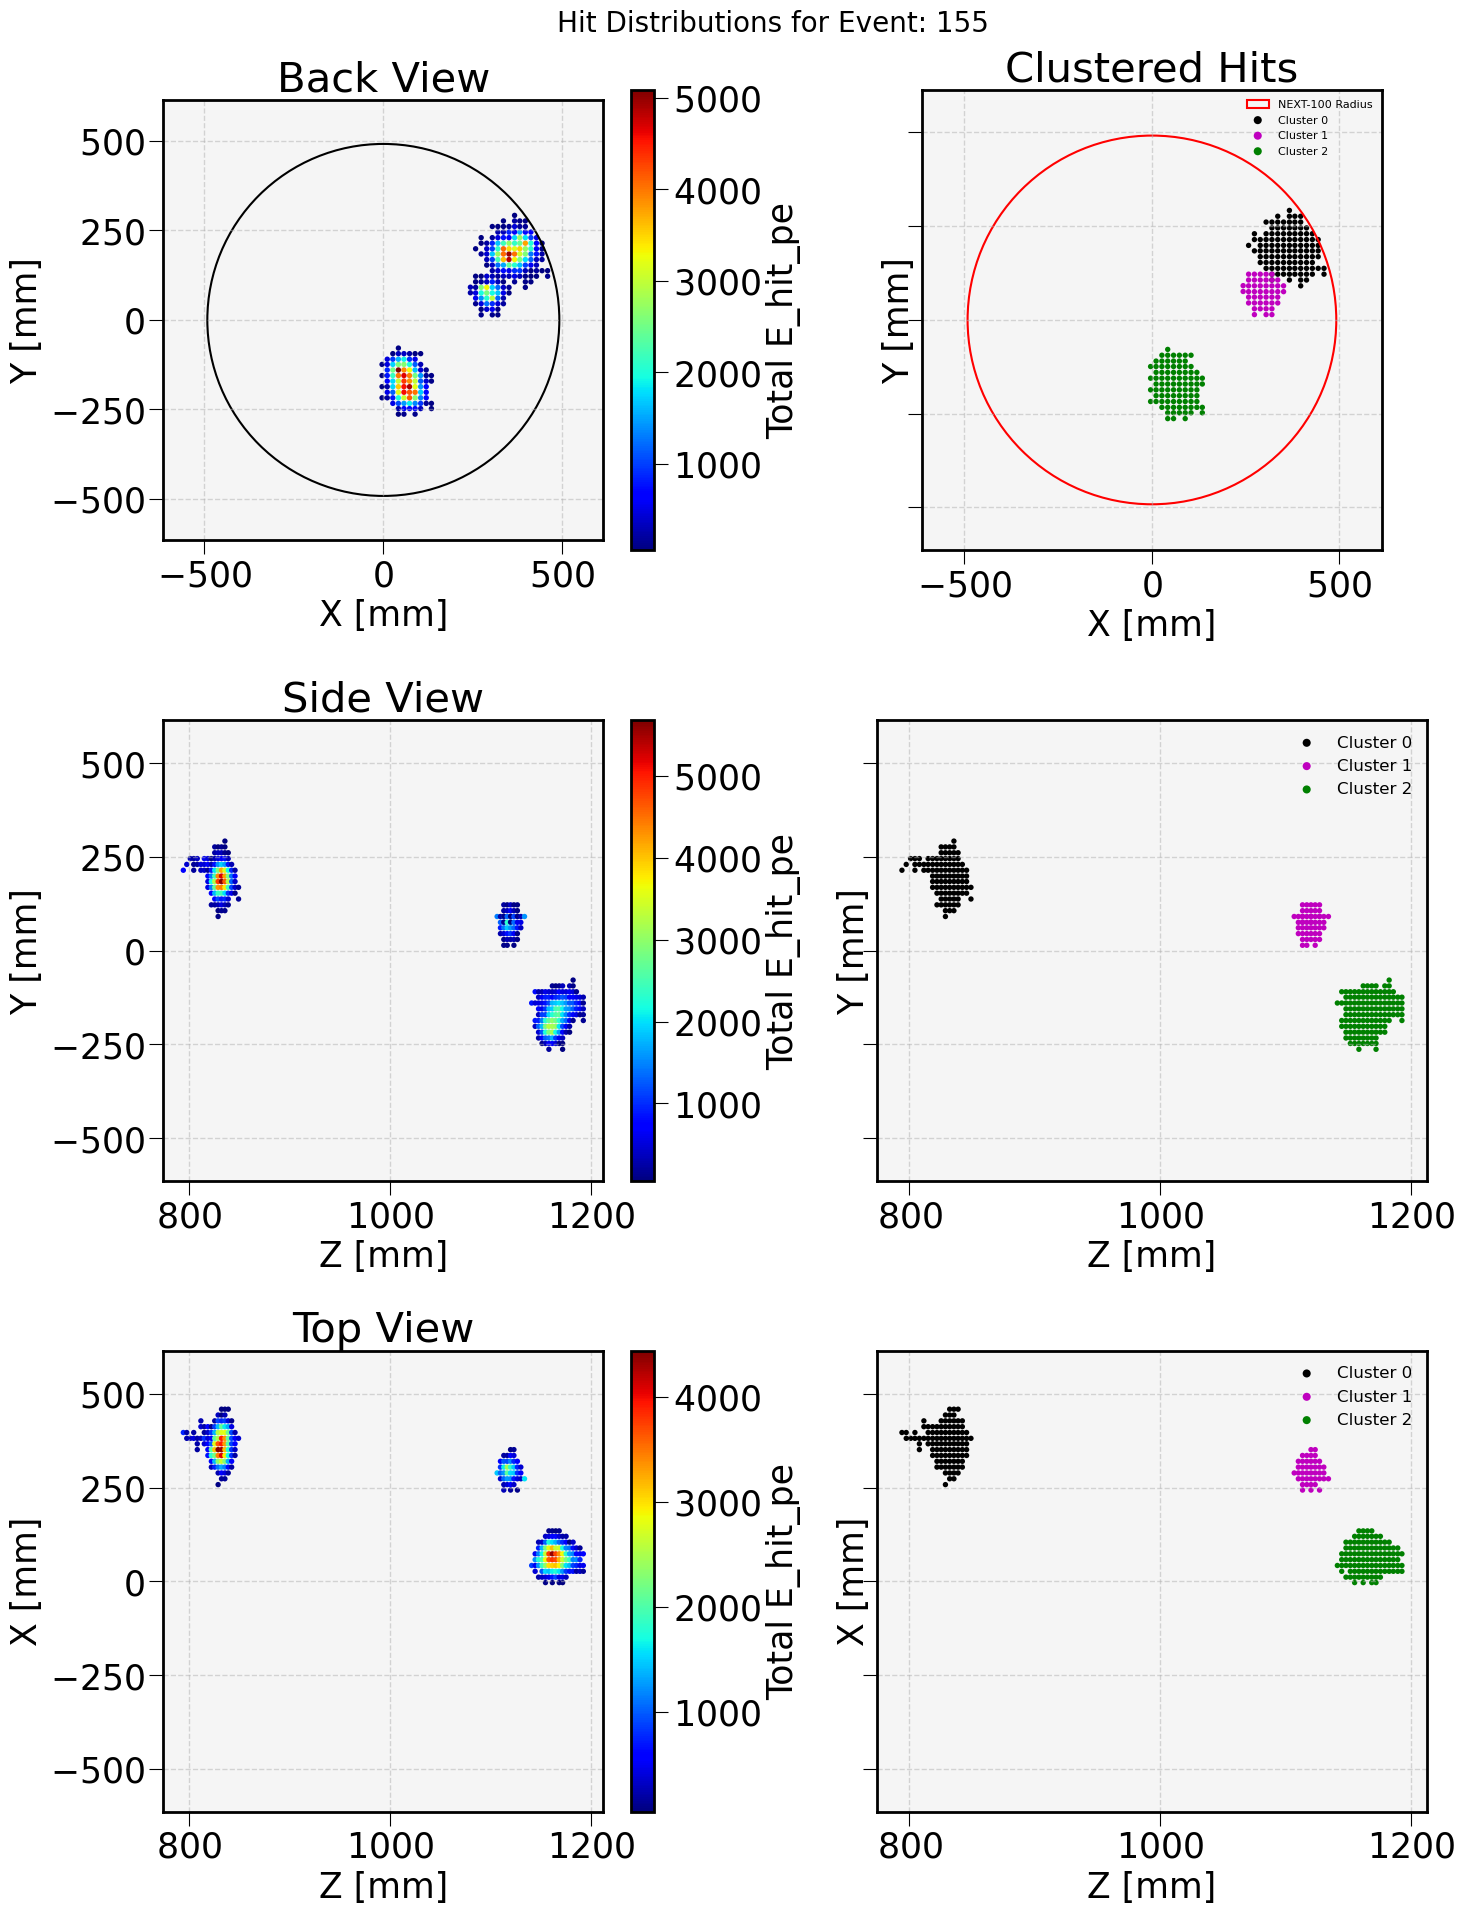

In [70]:
crudo.pt.display_event_cluster(clean_soph_df, variable='E_hit_pe', event=evt_test_id)

In the end, this clean topology is artificial, it depends on the parameters of clusterizer function.
<br>
I deeem storing the hit size of each event is important, but should be taken from the _original_ Sophronia dataframe.

In [ ]:
# Hits per event
original_evt_size_df = df_soph.groupby('event').size().rename('n_hits').reset_index()
clean_evt_size_df    = clean_soph_df.groupby('event').size().rename('n_hits').reset_index()

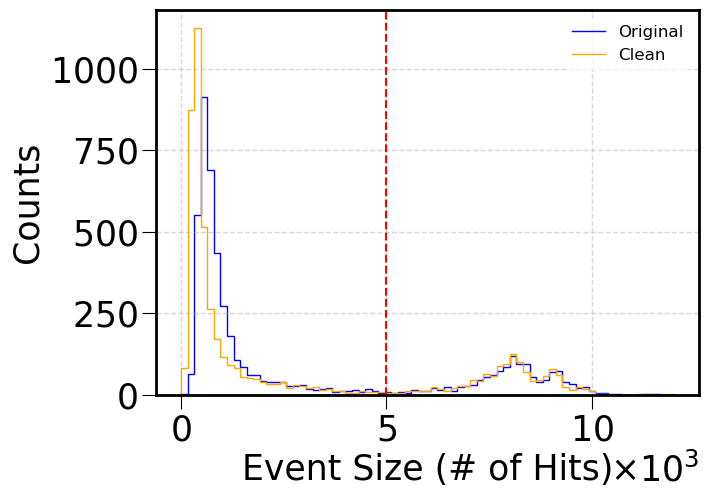

In [ ]:
# Histogram
og_hits_counts, edges = np.histogram(original_evt_size_df['n_hits'], bins=75, range=(0, 12e3))      # There are values up to ~25e3 hits
cl_hits_counts, _     = np.histogram(clean_evt_size_df['n_hits'], bins=edges)

# Plotting
plt.figure(figsize=(7, 5))
plt.stairs(og_hits_counts, edges, fill=False, ec='blue', lw=1.0, label='Original')
plt.stairs(cl_hits_counts, edges, fill=False, ec='orange', lw=1.0, label='Clean')

plt.axvline(x=5e3, color='red', ls='--', lw=1.5)    # Possible hit size cut

# Styling
plt.xlabel('Event Size (# of Hits)')
plt.ylabel('Counts')
# plt.yscale('log')
plt.ticklabel_format(axis='x', style='sci', scilimits=(3, 3))
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

In any case, it is hard to trust in this variable. It suffers the same effect as energy event.
<br>
Some degraded alphas may have lower number of hits ~ electron size.
<br>
Although, this information together with the energies can help us a lot with tagging alpha/electron-like events. ~~So I store both: original and clean.~~

#### Update

We do not save the clean dataframe yet, cause' I need old Sophronia dataframe for storage purposes.

In [ ]:
after_hits_treatment_ids = clean_soph_df['event'].unique()
df_doro, df_soph = crudo.dm.apply_cut_and_update(df_doro, df_soph, event_ids=after_hits_treatment_ids)
print(f"After dealing with spurious hits: {df_soph['event'].nunique()} events.")

After dealing with spurious hits: 5157 events.


### Removing $Z\leq0$

Remove every event that has hits with negative $Z$ position.
<br>
This is done in Sophronia, although you will find that for some events that passed the Sophronia filter, some $[S1,\,S2]$ peak combinations may still have negative $Z$ value in Dorothea.
<br>
Due to the unsyncronized peak tagging in both dataframes, we must accept these peak combinations in Dorothea.

---
__UPDATE:__ It is moment to understand these guys!

In [6]:
reco_ids = df_soph['event'].unique()
events_with_negative_z_hits = df_soph.loc[df_soph['Z'] < 0, 'event'].unique()

#### Negative events

In [7]:
Z_neg_doro_df, Z_neg_soph_df = crudo.dm.apply_cut_and_update(df_doro, df_soph, event_ids=events_with_negative_z_hits)
Z_neg_soph_df

,event,time,npeak,Xpeak,Ypeak,nsipm,X,Y,Xrms,Yrms,DT,Q,E,Qc,Ec,track_id,Ep,Z
2377,36,1.751990e+09,15,-19.686995,75.244048,1,-467.075,90.925,0.0,0.0,-249.294813,9.208463,1.335000,-1.0,0.000012,-1,-1.0,-215.640013
2378,36,1.751990e+09,15,-19.686995,75.244048,1,-265.925,153.125,0.0,0.0,-243.145187,7.912636,-4.387025,-1.0,-0.000023,-1,-1.0,-210.320587
2379,36,1.751990e+09,15,-19.686995,75.244048,1,427.825,260.975,0.0,0.0,-237.075187,7.130562,3.549627,-1.0,NaN,-1,-1.0,-205.070037
2380,36,1.751990e+09,15,-19.686995,75.244048,1,-220.275,414.975,0.0,0.0,-232.498500,12.262051,31.948721,-1.0,0.000251,-1,-1.0,-201.111202
2381,36,1.751990e+09,15,-19.686995,75.244048,1,412.275,214.325,0.0,0.0,-228.909125,8.203541,225.079778,-1.0,0.001619,-1,-1.0,-198.006393
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15325289,366759,1.751998e+09,45,50.068540,200.118051,1,88.725,414.975,0.0,0.0,2490.379250,7.110618,64.756268,-1.0,0.000415,-1,-1.0,2154.178051
15325290,366759,1.751998e+09,45,50.068540,200.118051,1,88.725,430.525,0.0,0.0,2490.379250,10.929811,99.537583,-1.0,0.000688,-1,-1.0,2154.178051
15325291,366759,1.751998e+09,45,50.068540,200.118051,1,88.725,446.075,0.0,0.0,2490.379250,7.465641,67.989455,-1.0,0.000499,-1,-1.0,2154.178051
15325292,366759,1.751998e+09,45,50.068540,200.118051,1,73.175,430.525,0.0,0.0,2494.419250,7.784914,85.169517,-1.0,0.000586,-1,-1.0,2157.672651


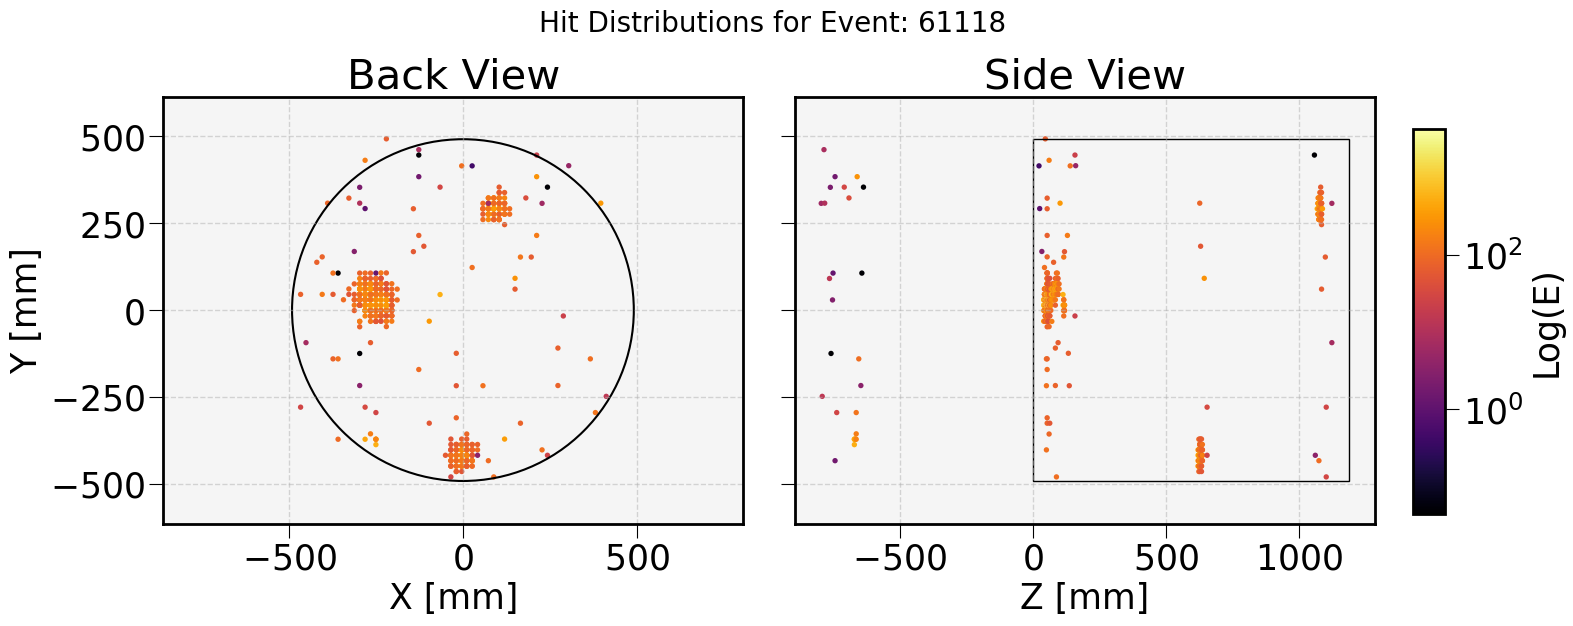

In [20]:
crudo.pt.event_display(Z_neg_soph_df, variable='E', event_column='event', event=None)

In [14]:
Z_neg_doro_df

,event,time,s1_peak,s2_peak,nS1,nS2,S1w,S1h,S1e,S1t,...,Nsipm,DT,Z,Zrms,X,Y,R,Phi,Xrms,Yrms
3,36,1.751990e+09,0,0,1,2,350.0,96.354874,550.225281,794600.0,...,720,-217.082382,-217.082382,5.347107,-19.686996,75.244049,77.776890,1.826702,243.367412,261.884574
4,36,1.751990e+09,0,1,1,2,350.0,96.354874,550.225281,794600.0,...,3576,612.885376,612.885376,84.420305,124.482545,31.112001,128.311577,0.244913,265.232105,218.003301
18,169,1.751990e+09,0,0,1,5,675.0,60.669781,368.434753,781225.0,...,2384,-222.727890,-222.727890,23.681955,-23.608417,-16.820878,28.987917,-2.522530,259.877705,256.612619
19,169,1.751990e+09,0,1,1,5,675.0,60.669781,368.434753,781225.0,...,241,72.249001,72.249001,4.031977,64.547839,-41.731755,76.863274,-0.573928,240.200894,220.867142
20,169,1.751990e+09,0,2,1,5,675.0,60.669781,368.434753,781225.0,...,3435,640.265503,640.265503,37.612613,158.700544,32.842636,162.063264,0.204067,254.084358,205.622238
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55340,366759,1.751998e+09,2,1,4,3,1000.0,5.080951,98.793053,349025.0,...,2709,1058.458618,1058.458618,16.958773,68.500643,110.245688,129.793874,1.014829,235.620236,258.247603
55341,366759,1.751998e+09,2,2,4,3,1000.0,5.080951,98.793053,349025.0,...,130,2415.455322,2415.455322,3.964181,50.068540,200.118050,206.286434,1.325634,195.451573,286.725758
55342,366759,1.751998e+09,3,0,4,3,550.0,18.538095,103.131638,877575.0,...,2204,-533.082703,-533.082703,28.710570,-20.833721,-10.787020,23.460685,-2.663832,247.867459,245.218822
55343,366759,1.751998e+09,3,1,4,3,550.0,18.538095,103.131638,877575.0,...,2709,529.908630,529.908630,16.958773,68.500643,110.245688,129.793874,1.014829,235.620236,258.247603


In [15]:
s1_mask = (Z_neg_doro_df['nS1'] == 0) | ((Z_neg_doro_df['nS1'] == 1) & (Z_neg_doro_df['S1h'] >= M_NOPOLIKE * Z_neg_doro_df['S1e'] + B_NOPOLIKE))
S1_neg_doro_df, S1_neg_soph_df = crudo.dm.apply_cut_and_update(Z_neg_doro_df, Z_neg_soph_df, cut_mask=s1_mask, df_for_mask=Z_neg_doro_df)

In [16]:
S1_neg_doro_df

,event,time,s1_peak,s2_peak,nS1,nS2,S1w,S1h,S1e,S1t,...,Nsipm,DT,Z,Zrms,X,Y,R,Phi,Xrms,Yrms
3,36,1.751990e+09,0,0,1,2,350.0,96.354874,550.225281,794600.0,...,720,-217.082382,-217.082382,5.347107,-19.686996,75.244049,77.776890,1.826702,243.367412,261.884574
4,36,1.751990e+09,0,1,1,2,350.0,96.354874,550.225281,794600.0,...,3576,612.885376,612.885376,84.420305,124.482545,31.112001,128.311577,0.244913,265.232105,218.003301
18,169,1.751990e+09,0,0,1,5,675.0,60.669781,368.434753,781225.0,...,2384,-222.727890,-222.727890,23.681955,-23.608417,-16.820878,28.987917,-2.522530,259.877705,256.612619
19,169,1.751990e+09,0,1,1,5,675.0,60.669781,368.434753,781225.0,...,241,72.249001,72.249001,4.031977,64.547839,-41.731755,76.863274,-0.573928,240.200894,220.867142
20,169,1.751990e+09,0,2,1,5,675.0,60.669781,368.434753,781225.0,...,3435,640.265503,640.265503,37.612613,158.700544,32.842636,162.063264,0.204067,254.084358,205.622238
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55323,366689,1.751998e+09,0,2,1,4,600.0,14.367283,83.231430,817575.0,...,2927,598.916931,598.916931,10.789866,64.983653,3.253963,65.065071,0.050032,253.099453,224.820524
55324,366689,1.751998e+09,0,3,1,4,600.0,14.367283,83.231430,817575.0,...,300,1170.921265,1170.921265,5.390896,96.322883,52.010269,109.467647,0.495100,281.295193,240.608579
55325,366703,1.751998e+09,0,0,1,3,650.0,83.721725,484.388458,462850.0,...,695,22.626032,22.626032,7.608129,18.766271,7.045524,20.045257,0.359152,252.029714,247.619574
55326,366703,1.751998e+09,0,1,1,3,650.0,83.721725,484.388458,462850.0,...,2711,83.632256,83.632256,43.059789,21.309815,3.936262,21.670311,0.182657,219.554144,255.158239


In [17]:
S1_corr_neg_doro_df = crudo.ef.correct_S1e(S1_neg_doro_df, CV_FIT, DT_CATH, output_column='S1e_corr')
S1_max_neg_df = S1_corr_neg_doro_df.groupby('event')['S1e'].max().rename('S1e_corr_max').reset_index()
S1_max_neg_df

,event,S1e_corr_max
0,36,550.225281
1,169,368.434753
2,267,97.683144
3,946,316.391632
4,1051,122.365387
...,...,...
2983,366346,59.697433
2984,366423,102.119034
2985,366493,152.528015
2986,366689,83.231430


In [164]:
# s1_max_neg_df = Z_neg_doro_df.groupby('event')['S1e'].max().reset_index()
# s1_max_neg_df.rename(columns={'S1e': 'S1e_max'}, inplace=True)
# s1_max_neg_df

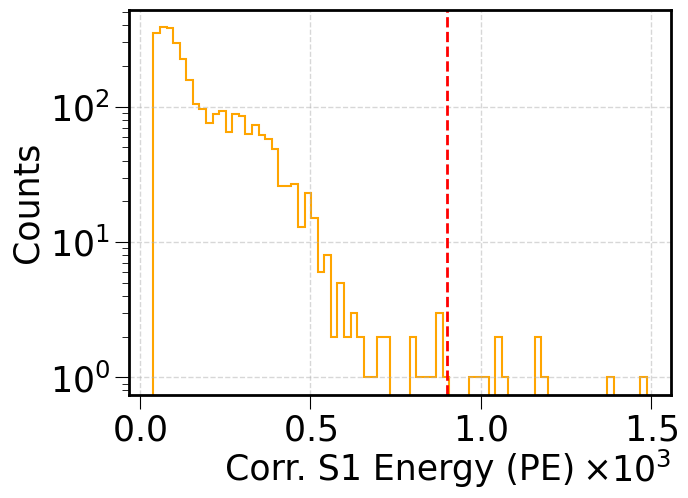

In [185]:
s1_counts, edges = np.histogram(S1_max_neg_df['S1e_corr_max'], bins=75)

plt.figure(figsize=(7, 5))
plt.stairs(s1_counts, edges, fill=False, ec='orange', lw=1.5)
plt.axvline(S1_ENERGY_THRESHOLD, color='red', linestyle='--', label=f'S1 Energy Threshold ({S1_ENERGY_THRESHOLD} PE)')
plt.xlabel('Corr. S1 Energy (PE)')
plt.ylabel('Counts')
plt.yscale('log')
plt.ticklabel_format(axis='x', style='sci', scilimits=(0, 0))
plt.grid(True)
plt.show()

In [ ]:

events_with_positive_z_hits = np.setdiff1d(reco_ids, events_with_negative_z_hits)
Z_pos_doro_df, Z_pos_soph_df = crudo.dm.apply_cut_and_update(df_doro, df_soph, event_ids=events_with_positive_z_hits)

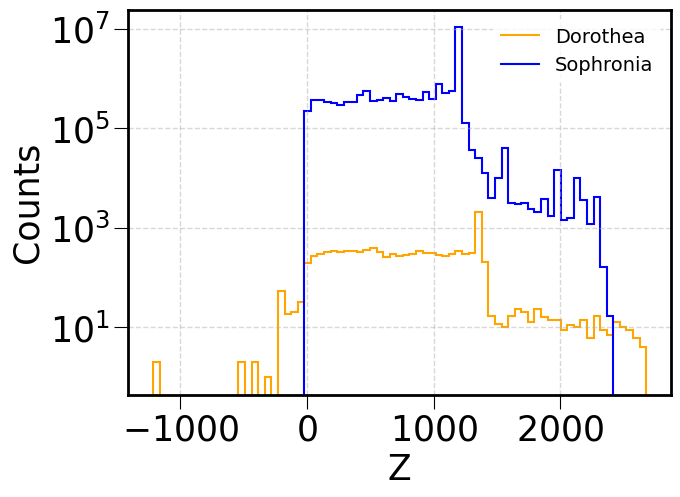

In [8]:
# Drop NaN values from the 'Z' column before creating histograms
Z_doro_clean = Z_pos_doro_df['Z'].dropna()      # nS1 = 0 has NaN Z values
Z_soph_clean = Z_pos_soph_df['Z'].dropna()

# Binning
Z_doro, edges = np.histogram(Z_doro_clean, bins=75)
Z_soph, _     = np.histogram(Z_soph_clean, bins=edges)

plt.figure(figsize=(7, 5))
plt.stairs(Z_doro, edges, fill=False, ec='orange', lw=1.5, label='Dorothea')
plt.stairs(Z_soph, edges, fill=False, ec='blue', lw=1.5, label='Sophronia')
plt.xlabel('Z')
plt.ylabel('Counts')
plt.yscale('log')
plt.legend(fontsize=14)
plt.grid(True)
plt.show()

In [16]:
df_doro = Z_pos_doro_df.copy()
df_soph = Z_pos_soph_df.copy()
print(f"After removing events with hits at negative Z: {df_soph['event'].nunique()} events.")

After removing events with hits at negative Z: 6138 events.


### Energy Correction

Correction value @ center of anode: [0.96918666]


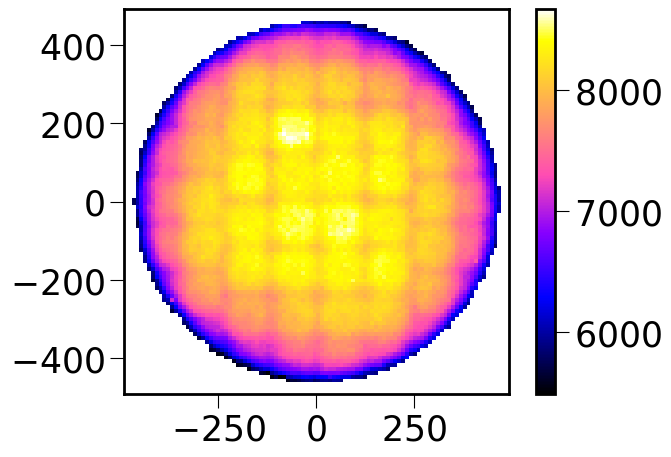

In [10]:
# Select the Kr file you want to use
# kr_test_path = '/lhome/ific/c/ccortesp/Analysis/NEXT-100/Th_analysis/h5/combined_15546_15557_zemrude_map.h5'
# kr_test_path = '/lhome/ific/c/ccortesp/Analysis/NEXT-100/Th_analysis/h5/combined_15730_15737_zemrude_map.h5'
# kr_test_path = '/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/h5/krmap_3D_15737.h5'
kr_test_path = KR_PATH

# Kr map loading
kr_map_df = pd.read_hdf(kr_test_path, key='krmap/krmap')    # 'krmap/krmap' or just 'krmap'

# Check the map in the anode region (k=0)
zem_map = kr_map_df[kr_map_df['k'] == 0].copy()
plt.figure(figsize=(7, 5))
plt.imshow(zem_map['mu'].values.reshape(100, 100).T, origin='lower', extent=(-crudo.pt.N100_rad, crudo.pt.N100_rad,-crudo.pt.N100_rad, crudo.pt.N100_rad))
plt.colorbar()

corr3d = crudo.ef.get_corr3d(kr_test_path, norm_method=NormMethod.median_anode)     # If this fails look at the used key in the function
print(f'Correction value @ center of anode: {corr3d([0], [0], [0])}')

In [11]:
# How is the time evolution of energy scale?
kr_time_df = pd.read_hdf(kr_test_path, key='t_evol/t_evol')
kr_time_df.ts.value_counts()

1757590302    1
1757597502    1
1757604702    1
1757611902    1
1757619102    1
1757626302    1
1757633502    1
1757640702    1
1757647902    1
1757655102    1
1757662302    1
1757669502    1
Name: ts, dtype: int64

#### Apply $^{83\text{m}}\text{Kr}$ correction

In [17]:
df_soph

,event,time,npeak,Xpeak,Ypeak,nsipm,X,Y,Xrms,Yrms,DT,Q,E,Qc,Ec,track_id,Ep,Z
4122,2780,1.757590e+09,34,68.413708,-49.017391,1,-482.625,292.075,0.0,0.0,1279.200000,6.333891,-0.368824,-1.0,NaN,-1,-1.0,1106.508000
4123,2780,1.757590e+09,34,68.413708,-49.017391,1,-34.675,-479.925,0.0,0.0,1279.200000,6.688568,-0.389477,-1.0,-3.999281e-06,-1,-1.0,1106.508000
4124,2780,1.757590e+09,34,68.413708,-49.017391,1,-50.225,260.475,0.0,0.0,1279.200000,5.095693,-0.296723,-1.0,-1.601593e-06,-1,-1.0,1106.508000
4125,2780,1.757590e+09,34,68.413708,-49.017391,1,-112.425,-124.275,0.0,0.0,1283.702375,7.986892,0.690163,-1.0,3.730468e-06,-1,-1.0,1110.402554
4126,2780,1.757590e+09,34,68.413708,-49.017391,1,-50.225,414.975,0.0,0.0,1283.702375,8.842202,0.764072,-1.0,4.616623e-06,-1,-1.0,1110.402554
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30510616,3248016,1.757676e+09,25,150.533371,154.025111,1,-81.325,-139.825,0.0,0.0,196.639500,5.287207,2.361786,-1.0,1.194020e-05,-1,-1.0,170.093167
30510617,3248016,1.757676e+09,25,150.533371,154.025111,1,366.625,384.375,0.0,0.0,196.639500,6.403054,2.860233,-1.0,NaN,-1,-1.0,170.093167
30510618,3248016,1.757676e+09,25,150.533371,154.025111,1,-451.525,214.325,0.0,0.0,201.007000,5.187193,-0.141041,-1.0,NaN,-1,-1.0,173.871055
30510619,3248016,1.757676e+09,25,150.533371,154.025111,1,-220.275,-247.675,0.0,0.0,201.007000,5.456049,-0.148351,-1.0,-7.984915e-07,-1,-1.0,173.871055


In [ ]:
# Apply Kr correction & clean negative/NaN values
# corr_soph = bf.correct_energy_by_map(df_soph, read_maps(KR_PATH))
corr_soph = crudo.ef.correct_energy_by_kr_map(df_soph, kr_test_path, norm_method=NormMethod.median_anode, mev_units=False, output_col='Ec')
corr_soph

,event,time,npeak,Xpeak,Ypeak,nsipm,X,Y,Xrms,Yrms,DT,Q,E,Qc,Ec,track_id,Ep,Z
4122,2780,1.757590e+09,34,68.413708,-49.017391,1,-482.625,292.075,0.0,0.0,1279.200000,6.333891,-0.368824,-1.0,0.000000,-1,-1.0,1106.508000
4123,2780,1.757590e+09,34,68.413708,-49.017391,1,-34.675,-479.925,0.0,0.0,1279.200000,6.688568,-0.389477,-1.0,0.000000,-1,-1.0,1106.508000
4124,2780,1.757590e+09,34,68.413708,-49.017391,1,-50.225,260.475,0.0,0.0,1279.200000,5.095693,-0.296723,-1.0,0.000000,-1,-1.0,1106.508000
4125,2780,1.757590e+09,34,68.413708,-49.017391,1,-112.425,-124.275,0.0,0.0,1283.702375,7.986892,0.690163,-1.0,0.685254,-1,-1.0,1110.402554
4126,2780,1.757590e+09,34,68.413708,-49.017391,1,-50.225,414.975,0.0,0.0,1283.702375,8.842202,0.764072,-1.0,0.856769,-1,-1.0,1110.402554
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30510616,3248016,1.757676e+09,25,150.533371,154.025111,1,-81.325,-139.825,0.0,0.0,196.639500,5.287207,2.361786,-1.0,2.271201,-1,-1.0,170.093167
30510617,3248016,1.757676e+09,25,150.533371,154.025111,1,366.625,384.375,0.0,0.0,196.639500,6.403054,2.860233,-1.0,3.872851,-1,-1.0,170.093167
30510618,3248016,1.757676e+09,25,150.533371,154.025111,1,-451.525,214.325,0.0,0.0,201.007000,5.187193,-0.141041,-1.0,0.000000,-1,-1.0,173.871055
30510619,3248016,1.757676e+09,25,150.533371,154.025111,1,-220.275,-247.675,0.0,0.0,201.007000,5.456049,-0.148351,-1.0,0.000000,-1,-1.0,173.871055


What does the corrected energy spectrum look like now?

In [20]:
# Dataframe with energy per peak per event
event_df = corr_soph.groupby(['event']).agg(
                                                # Uncorrected
                                                X = ('X', lambda x: crudo.ut.weighted_avg(x, corr_soph.loc[x.index, 'E'])),
                                                Y = ('Y', lambda y: crudo.ut.weighted_avg(y, corr_soph.loc[y.index, 'E'])),
                                                Z = ('Z', lambda z: crudo.ut.weighted_avg(z, corr_soph.loc[z.index, 'E'])),
                                                E_evt = ('E', 'sum'), 
                                                # Corrected
                                                Xc = ('X', lambda x: crudo.ut.weighted_avg(x, corr_soph.loc[x.index, 'Ec'])),
                                                Yc = ('Y', lambda y: crudo.ut.weighted_avg(y, corr_soph.loc[y.index, 'Ec'])),
                                                Zc = ('Z', lambda z: crudo.ut.weighted_avg(z, corr_soph.loc[z.index, 'Ec'])),
                                                Ec_evt = ('Ec', 'sum')).reset_index()

event_df

,event,X,Y,Z,E_evt,Xc,Yc,Zc,Ec_evt
0,380,-314.178662,-261.289426,362.745390,1.510146e+05,-319.922293,-265.807889,361.001280,1.878257e+05
1,534,215.165898,142.412889,669.935932,1.074857e+06,219.231585,145.368025,669.945456,1.160271e+06
2,751,-338.194826,-207.347366,303.655723,1.957877e+05,-346.735718,-212.206668,303.590012,2.388086e+05
3,1038,283.417705,214.236067,719.756261,4.926312e+05,286.979143,216.918385,719.758503,5.488286e+05
4,1388,-229.381903,235.390689,80.791964,2.383796e+05,-243.223972,249.480075,80.810785,2.836694e+05
...,...,...,...,...,...,...,...,...,...
6133,3245643,-75.903723,60.984296,1038.416148,7.886677e+05,-76.001308,60.831616,1033.723362,8.481187e+05
6134,3247127,314.267001,-177.130109,151.950323,2.679085e+05,327.564727,-184.033848,151.915466,3.209068e+05
6135,3247302,227.608343,-194.581126,1186.366220,7.100202e+05,228.650443,-195.541035,1186.371370,7.525275e+05
6136,3248016,271.640317,273.738951,89.855266,1.970979e+05,282.469138,284.566559,89.770628,2.459153e+05


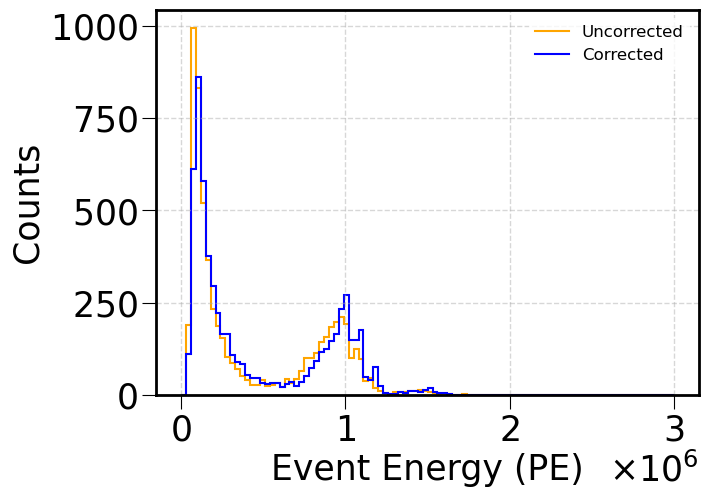

In [21]:
# Histogram
E_counts, edges = np.histogram(event_df['E_evt'], bins=100, range=(0, 3e6))
Ec_counts, _    = np.histogram(event_df['Ec_evt'], bins=edges)

# Plotting
plt.figure(figsize=(7, 5))
plt.stairs(E_counts, edges, fill=False, ec='orange', lw=1.5, label='Uncorrected')
plt.stairs(Ec_counts, edges, fill=False, ec='blue', lw=1.5, label='Corrected')

# plt.axvline(x=0.75e6, color='red', ls='--', lw=1.5)  # Possible energy cut -> REMEMBER, THERE ARE SPURIOUS HITS HERE!

# Styling
plt.xlabel('Event Energy (PE)')
plt.ylabel('Counts')
# plt.yscale('log')
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

__NOTE:__ I must think in a good ando direct way to check the correction in the dataset.

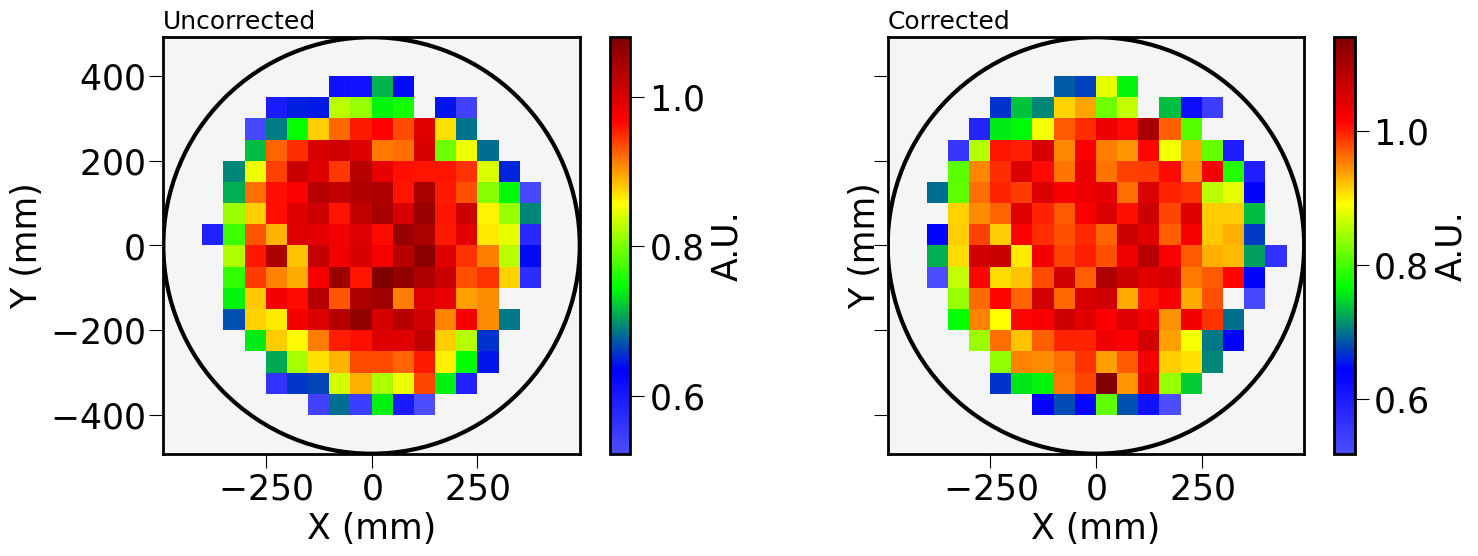

In [ ]:
# Global
n_bins = 25
masking = True

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
for i, data in enumerate(['Uncorrected', 'Corrected']):

    if data == 'Uncorrected':
        X = event_df['X'];  Y = event_df['Y']
        Z = event_df['Z'];  E = event_df['E_evt']
    elif data == 'Corrected':
        X = event_df['Xc']; Y = event_df['Yc']
        Z = event_df['Zc']; E = event_df['Ec_evt']

    # Masking
    if masking:
        time_mask = (Z > 1150)  # Cathode
        energy_mask = (0.5e6 <= E) & (E <= 2e6) # Alphas
        X = X[time_mask & energy_mask];  Y = Y[time_mask & energy_mask]
        Z = Z[time_mask & energy_mask];  E = E[time_mask & energy_mask]

    # XY map
    S2e_XY_map, x_edges, y_edges = crudo.pt.mapping(X, Y, wei=E, xy_bins=n_bins, norm=True)
    S2e_XY_map                   = np.ma.masked_where(S2e_XY_map == 0, S2e_XY_map)
    # Mask values outside the range [0, 2] in the Z-axis
    # S2e_XY_map = np.ma.masked_outside(S2e_XY_map, 0.8, 1.2)

    # Plot
    pcm = axes[i].pcolormesh(x_edges, y_edges, S2e_XY_map.T, cmap=crudo.pt.custom_hsv, shading='auto')
    cbar = fig.colorbar(pcm, ax=axes[i], label='A.U.')
    axes[i].set_xlabel('X (mm)')
    axes[i].set_xlim(-crudo.pt.N100_rad, crudo.pt.N100_rad)
    axes[i].set_ylabel('Y (mm)')
    axes[i].set_ylim(-crudo.pt.N100_rad, crudo.pt.N100_rad)
    axes[i].set_title(data, fontsize=18, loc='left')

    axes[i].set_aspect('equal', adjustable='box')
    axes[i].set_facecolor('whitesmoke')
    axes[i].add_patch(crudo.pt.plot_circle(crudo.pt.N100_rad))

plt.tight_layout()
plt.show()

In [14]:
# # Global
# n_bins = 40
# masking = True

# fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
# for i, (energy, label) in enumerate(zip(['E', 'E_corr_pe'], ['Unc. Energy', 'Kr-Corr. Energy'])):

#     # Variables
#     X = corr_soph['X'];   Y  = corr_soph['Y']
#     Z = corr_soph['Z'];   DT = corr_soph['DT']
#     E = corr_soph[energy]

#     # Masking
#     if masking:
#         time_mask = (DT > 0.9*DT_CATH)
#         X = X[time_mask];  Y = Y[time_mask]
#         Z = Z[time_mask];  E = E[time_mask]

#     # XY map
#     S2e_XY_map, x_edges, y_edges = crudo.pt.mapping(X, Y, wei=E, xy_bins=n_bins, norm=True)
#     S2e_XY_map                   = np.ma.masked_where(S2e_XY_map == 0, S2e_XY_map)
#     # Mask values outside the range [0, 2] in the Z-axis
#     # S2e_XY_map = np.ma.masked_outside(S2e_XY_map, 0, 2)

#     # Plot
#     pcm = axes[i].pcolormesh(x_edges, y_edges, S2e_XY_map.T, cmap=crudo.pt.custom_hsv, shading='auto')
#     cbar = fig.colorbar(pcm, ax=axes[i], label='Factor')
#     axes[i].set_xlabel('X (mm)')
#     axes[i].set_xlim(-crudo.pt.N100_rad, crudo.pt.N100_rad)
#     axes[i].set_ylabel('Y (mm)')
#     axes[i].set_ylim(-crudo.pt.N100_rad, crudo.pt.N100_rad)
#     axes[i].set_title(label, fontsize=18, loc='left')

#     axes[i].set_aspect('equal', adjustable='box')
#     axes[i].set_facecolor('whitesmoke')
#     axes[i].add_patch(crudo.pt.plot_circle(crudo.pt.N100_rad))

# plt.tight_layout()
# plt.show()

#### Update

In [22]:
# New dataframe with corrected energy per hit
df_soph = corr_soph.copy()

after_energy_correction_ids = df_soph['event'].unique()
df_doro, df_soph = crudo.dm.apply_cut_and_update(df_doro, df_soph, event_ids=after_energy_correction_ids)
print(f"After Kr energy correction: {df_soph['event'].nunique()} events.")

After Kr energy correction: 6138 events.


### $S1e$ Cut & Correction

#### $nS1\,\leq\,1$ (NO-Polike)

In [23]:
s1_mask = (df_doro['nS1'] == 0) | ((df_doro['nS1'] == 1) & (df_doro['S1h'] >= M_NOPOLIKE * df_doro['S1e'] + B_NOPOLIKE))
S1_doro_df, S1_soph_df = crudo.dm.apply_cut_and_update(df_doro, df_soph, cut_mask=s1_mask, df_for_mask=df_doro)

In [24]:
S1_doro_df['nS1'].value_counts()

1    5090
0     751
Name: nS1, dtype: int64

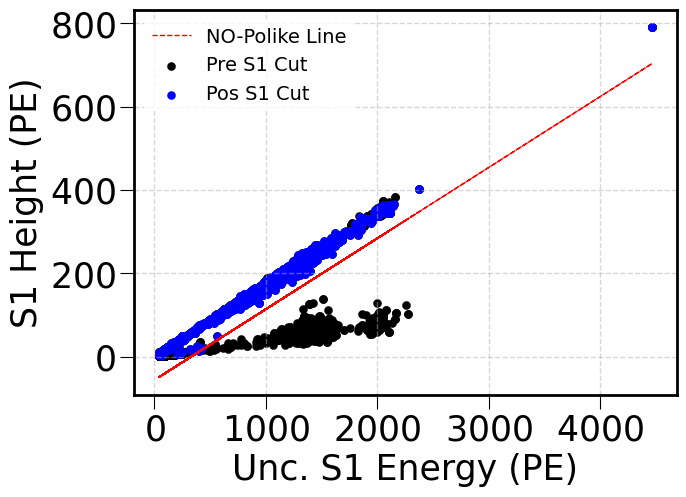

In [25]:
plt.figure(figsize=(7, 5))
plt.scatter(df_doro['S1e'], df_doro['S1h'], alpha=1.0, s=10, c='black', label='Pre S1 Cut')
plt.scatter(S1_doro_df['S1e'], S1_doro_df['S1h'], alpha=1.0, s=10, c='blue', label='Pos S1 Cut')
plt.plot(df_doro['S1e'], M_NOPOLIKE * df_doro['S1e'] + B_NOPOLIKE, c='red', ls='--', lw=1.0, label='NO-Polike Line')
plt.xlabel('Unc. S1 Energy (PE)')
plt.ylabel('S1 Height (PE)')
plt.legend(fontsize=14)
plt.grid(True)
plt.show()

#### $S1e$ correction

In [26]:
S1_corr_doro_df = crudo.ef.correct_S1e(S1_doro_df, CV_FIT, DT_CATH, output_column='S1e_corr')     # Based on alpha analysis

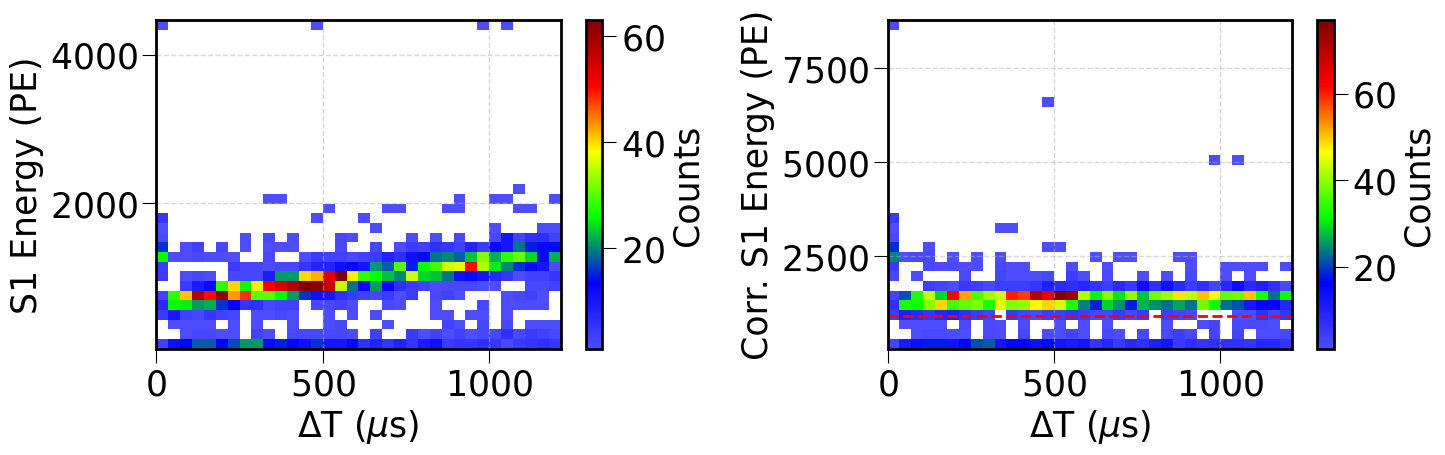

In [27]:
n_bins = 35
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for i, col in enumerate(['S1e', 'S1e_corr']):

    # Variables
    E1 = S1_corr_doro_df[col]
    DT = S1_corr_doro_df['DT']
    R = np.sqrt(S1_corr_doro_df['X']**2 + S1_corr_doro_df['Y']**2)

    # Masking
    rad_mask  = (R  < R_UP)
    time_mask = (DT < 0.9*DT_CATH)
    E1 = E1[rad_mask & time_mask]
    DT = DT[rad_mask & time_mask]

    # 2D histogram
    S1e_DT_map, ex, ey = crudo.pt.hist_2D(DT, E1, x_bins=n_bins, y_bins=n_bins)
    S1e_DT_map = np.ma.masked_where(S1e_DT_map == 0, S1e_DT_map)

    im = axes[i].pcolormesh(ex, ey, S1e_DT_map.T, cmap=crudo.pt.custom_hsv, shading='auto')
    cbar = plt.colorbar(im, ax=axes[i], label='Counts', shrink=1.0)
    axes[i].set_xlabel('$\Delta$T ($\mu$s)')
    axes[i].set_ylabel('Corr. S1 Energy (PE)' if col == 'S1e_corr' else 'S1 Energy (PE)')
    axes[i].grid(True)

    # Possible alpha/electron limit line
    if col == 'S1e_corr':
        axes[i].axhline(y=S1_ENERGY_THRESHOLD, color='red', ls='--')

plt.tight_layout()
plt.show()

Max. corrected $S1$ energy per event would be our main discriminator for alpha/electron tagging!
<br>
In particular, for events with bad energy $(S2)$ reconstruction (~ cathode region, where we have degraded alphas).

In [21]:
# Compute max S1e_corr per event
s1e_corr_max_df = S1_corr_doro_df.groupby('event')['S1e_corr'].max().rename('S1e_corr_max').reset_index()
# Merge back to Dorothea-ish dataframe
S1_corr_doro_df = S1_corr_doro_df.merge(s1e_corr_max_df, on='event', how='left')

In [28]:
df_doro = S1_corr_doro_df.copy()
df_soph = S1_soph_df.copy()

print(f"After S1 cut & correction: {df_soph['event'].nunique()} events.")

After S1 cut & correction: 5161 events.


### Data @ Event/Peak-level

#### From Dorothea & old Sophronia

In [38]:
original_evt_size_df = df_soph.groupby('event').size().rename('old_n_hits').reset_index()
df_doro = df_doro.merge(original_evt_size_df, on='event', how='left')

In [39]:
# df_doro.event.nunique()
df_doro

,event,time,s1_peak,s2_peak,nS1,nS2,S1w,S1h,S1e,S1t,...,Z,Zrms,X,Y,R,Phi,Xrms,Yrms,S1e_corr,old_n_hits
0,2780,1.757590e+09,0,0,1,2,675.0,23.869015,163.272537,49775.0,...,1356.715332,11.355160,68.413708,-49.017390,84.161392,-0.621704,246.832267,244.285689,162.874434,829
1,2780,1.757590e+09,0,1,1,2,675.0,23.869015,163.272537,49775.0,...,2093.729736,5.269500,9.562074,30.176289,31.655042,1.263932,244.285141,254.165375,128.490126,829
2,4026,1.757590e+09,0,0,1,1,625.0,160.292587,948.692139,970925.0,...,437.564636,7.387824,28.829471,226.713690,228.539352,1.444313,185.919559,279.850563,1420.423478,550
3,4866,1.757590e+09,0,0,1,1,325.0,173.260468,1005.926208,469975.0,...,935.513428,9.827193,75.621530,-118.795674,140.822683,-1.003922,237.265708,286.018191,1184.646575,519
4,8275,1.757591e+09,0,0,1,1,700.0,202.752777,1230.435791,305425.0,...,1101.066040,7.435613,151.126449,162.359495,221.810300,0.821216,238.039099,239.455713,1353.028881,489
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5832,3242731,1.757676e+09,0,0,1,1,600.0,156.487976,943.453796,1028550.0,...,379.937653,7.348002,207.271146,-9.839301,207.504553,-0.047435,289.574764,193.496942,1458.380244,1082
5833,3244663,1.757676e+09,0,0,1,1,775.0,196.558121,1231.198364,247025.0,...,1160.456665,9.076452,-53.819741,139.782330,149.785394,1.938327,229.423873,278.587471,1322.432375,536
5834,3245468,1.757676e+09,0,0,1,1,650.0,203.132034,1177.925171,47700.0,...,1369.788940,8.562515,-87.209477,158.698664,181.082188,2.073278,184.929167,214.934782,1169.501563,6677
5835,3247127,1.757676e+09,0,0,1,1,775.0,149.324356,835.464966,1231775.0,...,174.714630,6.268220,177.541889,-92.395233,200.144951,-0.479845,271.487549,219.603316,1460.035582,1727


In [40]:
doro_info_df = crudo.dm.summarize_dorothea_info(df_doro, event_level_cols=EVENT_LEVEL_COLS)
doro_info_df

,event,nS1,nS2,old_n_hits,time,S1e,S1e_corr,S1w,S1h,S1t,S2e,S2w,S2h,S2t,S2q
0,380,1,2,794,1.757590e+09,876.666138,1337.398393,350.0,147.086182,1003975.0,1.433790e+05,107.500,14071.665039,1407491.500,39364.437500
1,380,1,2,794,1.757590e+09,876.666138,1145.885735,350.0,147.086182,1003975.0,7.662707e+03,39.050,569.429749,1708483.375,2399.995850
2,534,1,1,8987,1.757590e+09,1276.016113,1614.859570,625.0,213.970703,639975.0,1.074862e+06,97.775,79702.273438,1413487.875,222920.562500
3,751,1,1,1067,1.757590e+09,890.968079,1401.031786,350.0,155.669357,1057725.0,1.957943e+05,169.425,21144.376953,1407490.875,58408.968750
4,1388,0,1,1778,1.757590e+09,NaN,NaN,NaN,NaN,NaN,2.383899e+05,165.500,63945.476562,1403504.625,64161.750000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5832,3244663,1,1,536,1.757676e+09,1231.198364,1322.432375,775.0,196.558121,247025.0,7.348948e+04,155.550,4416.937012,1407481.625,30893.839844
5833,3245468,1,1,6677,1.757676e+09,1177.925171,1169.501563,650.0,203.132034,47700.0,8.356585e+05,201.125,46828.800781,1417488.875,193577.937500
5834,3247127,1,1,1727,1.757676e+09,835.464966,1460.035582,775.0,149.324356,1231775.0,2.679158e+05,152.525,37116.636719,1406489.625,65060.812500
5835,3248016,1,1,1226,1.757676e+09,660.968567,1210.325277,675.0,116.844925,1302525.0,1.971098e+05,158.925,36807.648438,1405493.125,57764.132812


In [41]:
doro_info_df.nunique()

event         5157
nS1              2
nS2              4
old_n_hits    2603
time          5157
S1e           4508
S1e_corr      5090
S1w             34
S1h           4509
S1t           3720
S2e           5836
S2w           3717
S2h           5836
S2t           2773
S2q           5837
dtype: int64

#### From Sophronia (NO spurious hits)

In [42]:
clean_soph_df

,event,time,npeak,Xpeak,Ypeak,nsipm,X,Y,Xrms,Yrms,DT,Q,E,Qc,Ec,track_id,Ep,Z,cluster,E_hit_pe
0,2780,1.757590e+09,34,68.413708,-49.017391,1,196.575,-233.125,0.0,0.0,1340.696250,6.396241,200.093938,-1.0,199.274129,-1,-1.0,1159.702256,0,220.943917
1,2780,1.757590e+09,34,68.413708,-49.017391,1,288.875,-217.075,0.0,0.0,1340.696250,5.536588,173.201354,-1.0,177.353201,-1,-1.0,1159.702256,0,196.639228
2,2780,1.757590e+09,34,68.413708,-49.017391,1,227.675,-247.675,0.0,0.0,1344.491125,7.896646,174.694116,-1.0,178.469914,-1,-1.0,1162.984823,0,197.877376
3,2780,1.757590e+09,34,68.413708,-49.017391,1,243.225,-263.225,0.0,0.0,1344.491125,6.276373,138.849510,-1.0,145.066322,-1,-1.0,1162.984823,0,160.841357
4,2780,1.757590e+09,34,68.413708,-49.017391,1,243.225,-247.675,0.0,0.0,1344.491125,8.294915,183.504843,-1.0,189.878325,-1,-1.0,1162.984823,0,210.526379
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13666262,3248016,1.757676e+09,25,150.533371,154.025111,1,335.525,322.175,0.0,0.0,112.253500,5.654683,52.218720,-1.0,70.522672,-1,-1.0,97.099277,0,71.096662
13666263,3248016,1.757676e+09,25,150.533371,154.025111,1,335.525,337.725,0.0,0.0,112.253500,13.708557,126.593001,-1.0,173.531429,-1,-1.0,97.099277,0,174.943816
13666264,3248016,1.757676e+09,25,150.533371,154.025111,1,-19.125,369.325,0.0,0.0,116.452250,5.173365,70.630258,-1.0,73.381338,-1,-1.0,100.731196,0,73.978595
13666265,3248016,1.757676e+09,25,150.533371,154.025111,1,-65.775,430.525,0.0,0.0,116.452250,7.754490,105.869519,-1.0,120.364621,-1,-1.0,100.731196,0,121.344279


In [43]:
df_final_soph = clean_soph_df.loc[:, FINAL_SOPH_COLUMNS].copy()
df_final_soph

,event,time,npeak,X,Y,DT,Z,E_hit_pe,cluster
0,2780,1.757590e+09,34,196.575,-233.125,1340.696250,1159.702256,220.943917,0
1,2780,1.757590e+09,34,288.875,-217.075,1340.696250,1159.702256,196.639228,0
2,2780,1.757590e+09,34,227.675,-247.675,1344.491125,1162.984823,197.877376,0
3,2780,1.757590e+09,34,243.225,-263.225,1344.491125,1162.984823,160.841357,0
4,2780,1.757590e+09,34,243.225,-247.675,1344.491125,1162.984823,210.526379,0
...,...,...,...,...,...,...,...,...,...
13666262,3248016,1.757676e+09,25,335.525,322.175,112.253500,97.099277,71.096662,0
13666263,3248016,1.757676e+09,25,335.525,337.725,112.253500,97.099277,174.943816,0
13666264,3248016,1.757676e+09,25,-19.125,369.325,116.452250,100.731196,73.978595,0
13666265,3248016,1.757676e+09,25,-65.775,430.525,116.452250,100.731196,121.344279,0


In [45]:
soph_event_info_df = crudo.dm.summarize_hits_to_event_level(df_final_soph, energy_column='E_hit_pe')
soph_event_info_df

,event,E_evt_pe,n_cluster,n_hits,X_bary,Y_bary,Z_bary,X_min,X_max,Y_min,Y_max,Z_min,Z_max,R_max
0,380,1.878257e+05,8,515,-344.625543,-288.136116,357.873704,-482.625,181.025,-448.825,292.075,336.084829,622.240561,502.611178
1,534,1.150921e+06,1,8945,222.105337,145.859396,669.691638,-482.625,490.025,-479.925,492.725,653.750781,687.599745,534.190936
2,751,2.342999e+05,14,844,-362.535936,-223.257228,303.027320,-467.075,412.275,-448.825,446.075,290.608752,313.957264,496.294324
3,1388,2.818879e+05,1,1674,-246.142048,251.750051,80.567839,-482.625,474.475,-464.375,477.175,63.359520,101.193323,551.266774
4,2361,2.487215e+05,15,1002,-162.645615,391.149039,320.827633,-467.075,458.925,-433.275,477.175,311.270899,330.796868,499.230980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5152,3244663,8.637414e+04,1,355,-174.710191,407.707353,1003.283625,-281.475,-65.775,276.525,477.175,989.216595,1019.560254,497.497720
5153,3245468,8.587326e+05,1,6535,-123.269693,220.112937,1184.384803,-482.625,474.475,-479.925,492.725,1164.188579,1215.543845,498.467844
5154,3247127,3.168360e+05,1,1628,334.011523,-188.377796,151.393922,-482.625,474.475,-479.925,461.625,139.434973,170.480147,502.578458
5155,3248016,2.424439e+05,7,1086,290.588187,290.603396,89.317261,-451.525,490.025,-464.375,492.725,80.304654,100.731196,509.200880


In [48]:
# soph_peak_info_df = df_final_soph.groupby(['event', 'npeak']).agg(E_peak_pe = ('E_hit_pe', 'sum')).reset_index()
# soph_peak_info_df

#### Aggregate

In [49]:
# df_file = pd.merge(soph_peak_info_df, soph_event_info_df, on='event', how='left')
df_file = pd.merge(doro_info_df, soph_event_info_df, on='event', how='left')
df_file

,event,nS1,nS2,old_n_hits,time,S1e,S1e_corr,S1w,S1h,S1t,...,X_bary,Y_bary,Z_bary,X_min,X_max,Y_min,Y_max,Z_min,Z_max,R_max
0,380,1,2,794,1.757590e+09,876.666138,1337.398393,350.0,147.086182,1003975.0,...,-344.625543,-288.136116,357.873704,-482.625,181.025,-448.825,292.075,336.084829,622.240561,502.611178
1,380,1,2,794,1.757590e+09,876.666138,1145.885735,350.0,147.086182,1003975.0,...,-344.625543,-288.136116,357.873704,-482.625,181.025,-448.825,292.075,336.084829,622.240561,502.611178
2,534,1,1,8987,1.757590e+09,1276.016113,1614.859570,625.0,213.970703,639975.0,...,222.105337,145.859396,669.691638,-482.625,490.025,-479.925,492.725,653.750781,687.599745,534.190936
3,751,1,1,1067,1.757590e+09,890.968079,1401.031786,350.0,155.669357,1057725.0,...,-362.535936,-223.257228,303.027320,-467.075,412.275,-448.825,446.075,290.608752,313.957264,496.294324
4,1388,0,1,1778,1.757590e+09,NaN,NaN,NaN,NaN,NaN,...,-246.142048,251.750051,80.567839,-482.625,474.475,-464.375,477.175,63.359520,101.193323,551.266774
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5832,3244663,1,1,536,1.757676e+09,1231.198364,1322.432375,775.0,196.558121,247025.0,...,-174.710191,407.707353,1003.283625,-281.475,-65.775,276.525,477.175,989.216595,1019.560254,497.497720
5833,3245468,1,1,6677,1.757676e+09,1177.925171,1169.501563,650.0,203.132034,47700.0,...,-123.269693,220.112937,1184.384803,-482.625,474.475,-479.925,492.725,1164.188579,1215.543845,498.467844
5834,3247127,1,1,1727,1.757676e+09,835.464966,1460.035582,775.0,149.324356,1231775.0,...,334.011523,-188.377796,151.393922,-482.625,474.475,-479.925,461.625,139.434973,170.480147,502.578458
5835,3248016,1,1,1226,1.757676e+09,660.968567,1210.325277,675.0,116.844925,1302525.0,...,290.588187,290.603396,89.317261,-451.525,490.025,-464.375,492.725,80.304654,100.731196,509.200880


I do not put $S1$ energy @ peak-level cause' the unsyncronized tag of peaks between Dorothea and Sophronia

# Tagging

Now, with the final dataframes we can inspect the tagging of events by particle type and detector region.

## By Particle

Recall, we still have degradated alphas, so we need to establish a proper way to distinguish alphas from electrons

In [41]:
df_file

,event,npeak,E_peak_pe,X_bary,Y_bary,Z_bary,Z_min,Z_max,R_max,E_evt_pe,...,main_S1e,main_S1e_corr,main_S1w,main_S1h,main_S1t,main_S2e,main_S2w,main_S2h,main_S2t,main_S2q
0,178,11,5.585313e+03,253.428421,252.614260,904.951362,46.319263,1868.260248,509.200880,3.310899e+05,...,NaN,NaN,NaN,NaN,NaN,264022.593750,90.000,48477.250000,1405482.250,60548.492188
1,178,31,3.203509e+05,253.428421,252.614260,904.951362,46.319263,1868.260248,509.200880,3.310899e+05,...,NaN,NaN,NaN,NaN,NaN,264022.593750,90.000,48477.250000,1405482.250,60548.492188
2,178,48,5.153635e+03,253.428421,252.614260,904.951362,46.319263,1868.260248,509.200880,3.310899e+05,...,NaN,NaN,NaN,NaN,NaN,264022.593750,90.000,48477.250000,1405482.250,60548.492188
3,596,34,9.497592e+05,214.449184,164.074252,1185.541926,1161.675646,1205.836166,499.423574,9.497592e+05,...,1390.610352,1380.192650,350.0,246.651306,47750.0,906339.750000,135.675,49674.238281,1418487.500,201896.500000
4,711,27,9.231329e+04,-53.236295,255.169671,1174.600854,1156.610530,1194.143853,370.276290,9.231329e+04,...,113.308388,112.839575,700.0,20.737892,46075.0,94790.773438,370.175,3682.364502,1407489.625,66277.593750
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7187,1790071,32,1.725046e+05,-229.014698,-320.010695,278.281627,243.819821,308.944265,504.123324,1.725046e+05,...,144.188858,229.482413,600.0,25.064007,1082650.0,159537.343750,196.325,4075.479004,1411494.125,53259.515625
7188,1790260,29,1.025993e+06,315.009025,-83.275197,1162.544361,1135.543455,1183.414826,509.721106,1.025993e+06,...,1392.760620,1395.891983,850.0,247.636429,73650.0,934126.750000,121.650,51649.296875,1417486.750,205730.296875
7189,1790324,36,4.928176e+05,-236.551410,277.649896,299.373106,286.700033,316.634656,537.571024,4.928176e+05,...,925.511230,1458.815664,650.0,150.849915,1062875.0,430438.593750,123.150,47475.160156,1408490.500,105304.671875
7190,1790786,25,9.533714e+05,-121.297570,-133.106392,1184.429279,1163.551506,1207.965796,495.278181,9.533714e+05,...,1441.180054,1431.238275,700.0,246.000305,48400.0,949568.187500,117.500,53772.578125,1417484.250,215050.656250


In [ ]:
zero_s1_events_df = df_file[df_file['nS1'] == 0].copy()
print(f"Events with zero S1: {zero_s1_events_df['event'].nunique()} ({zero_s1_events_df['event'].nunique() / df_file['event'].nunique() :.2%})")
one_s1_events_df  = df_file[df_file['nS1'] == 1].copy()
print(f"Events with one S1: {one_s1_events_df['event'].nunique()} ({one_s1_events_df['event'].nunique() / df_file['event'].nunique() :.2%})")

Number of zero S1 events: 823 (12.56%)
Number of one S1 events: 5729 (87.44%)


Take a look to the energy spectrum

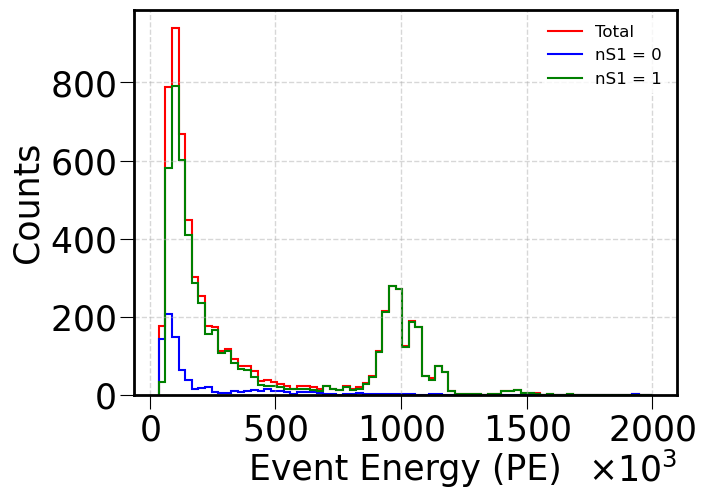

In [53]:
# Histogram
all_evt_counts, edges = np.histogram(df_file['E_evt_pe'].unique(), bins=75, range=(df_file['E_evt_pe'].min(), 2000e3))
zero_s1_evt_counts, _ = np.histogram(zero_s1_events_df['E_evt_pe'].unique(), bins=edges)
one_s1_evt_counts, _  = np.histogram(one_s1_events_df['E_evt_pe'].unique(), bins=edges)

# Plotting
plt.figure(figsize=(7, 5))
plt.stairs(all_evt_counts, edges, fill=False, ec='red', lw=1.5, label='Total')
plt.stairs(zero_s1_evt_counts, edges, fill=False, ec='blue', lw=1.5, label='nS1 = 0')
plt.stairs(one_s1_evt_counts, edges, fill=False, ec='green', lw=1.5, label='nS1 = 1')

# Styling
plt.xlabel('Event Energy (PE)')
plt.ylabel('Counts')
# plt.yscale('log')
plt.ticklabel_format(axis='x', style='sci', scilimits=(3, 3))
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

### $nS1 = 0$

In this case a good discriminator would be the _event size_ (# of hits)

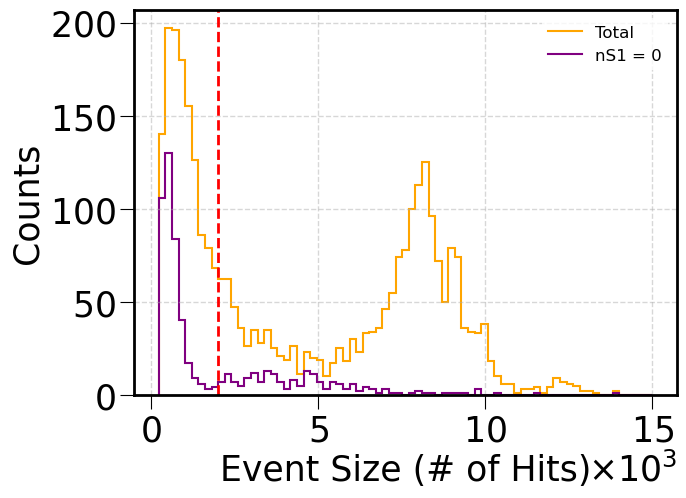

In [ ]:
# Histogram
evt_counts, edges = np.histogram(df_file['reco_size'].unique(), bins=75, range=(df_file['reco_size'].min(), 15e3))
zero_s1_counts, _ = np.histogram(zero_s1_events_df['reco_size'].unique(), bins=edges)

# Plotting
plt.figure(figsize=(7, 5))
plt.stairs(evt_counts, edges, fill=False, ec='orange', lw=1.5, label='Total')
plt.stairs(zero_s1_counts, edges, fill=False, ec='purple', lw=1.5, label='nS1 = 0')

plt.axvline(x=SIZE_THRESHOLD, color='red', ls='--')     # Event size cut

# Styling
plt.xlabel('Event Size (# of Hits)')
plt.ylabel('Counts')
# plt.yscale('log')
plt.ticklabel_format(axis='x', style='sci', scilimits=(3, 3))
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

In [66]:
zero_s1_elec_like  = zero_s1_events_df.loc[zero_s1_events_df['reco_size'] <= SIZE_THRESHOLD, 'event'].unique()
zero_s1_alpha_like = zero_s1_events_df.loc[zero_s1_events_df['reco_size'] >  SIZE_THRESHOLD, 'event'].unique()
print(f"Number of electron-like events: {len(zero_s1_elec_like)} ({len(zero_s1_elec_like) / zero_s1_events_df['event'].nunique() :.2%})")
print(f"Number of alpha-like events: {len(zero_s1_alpha_like)} ({len(zero_s1_alpha_like) / zero_s1_events_df['event'].nunique() :.2%})")

Number of electron-like events: 625 (75.94%)
Number of alpha-like events: 198 (24.06%)


Take a look to some event displays

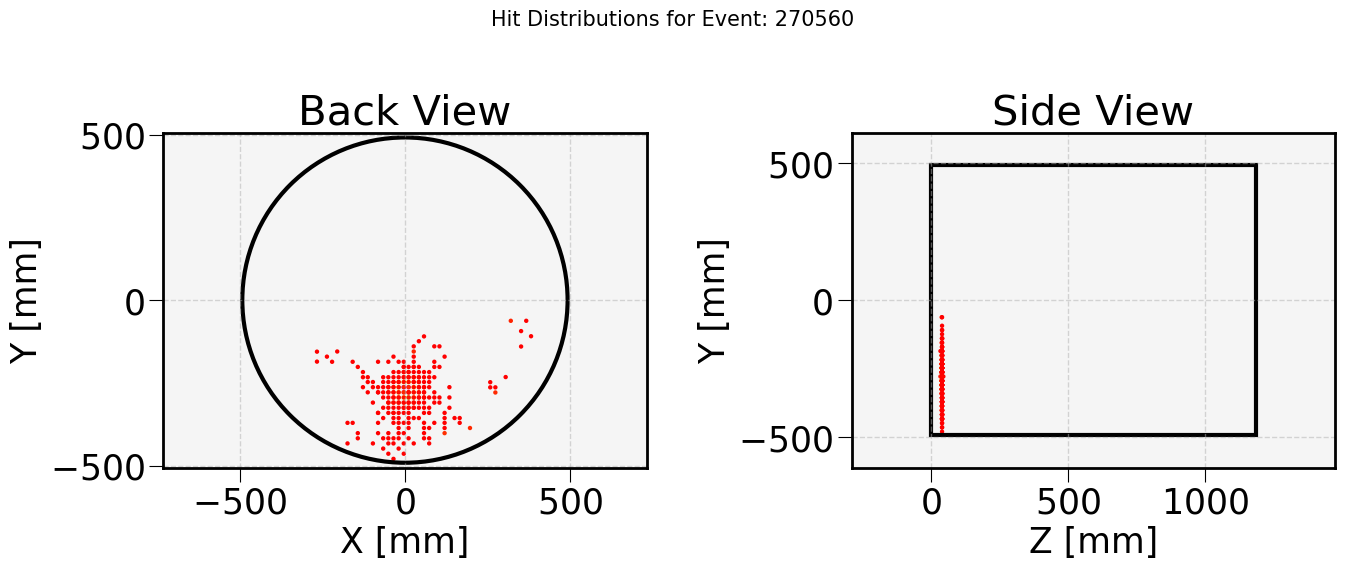

In [82]:
crudo.pt.event_display(df_final_soph, variable='E_hit_pe', event=np.random.choice(zero_s1_elec_like))

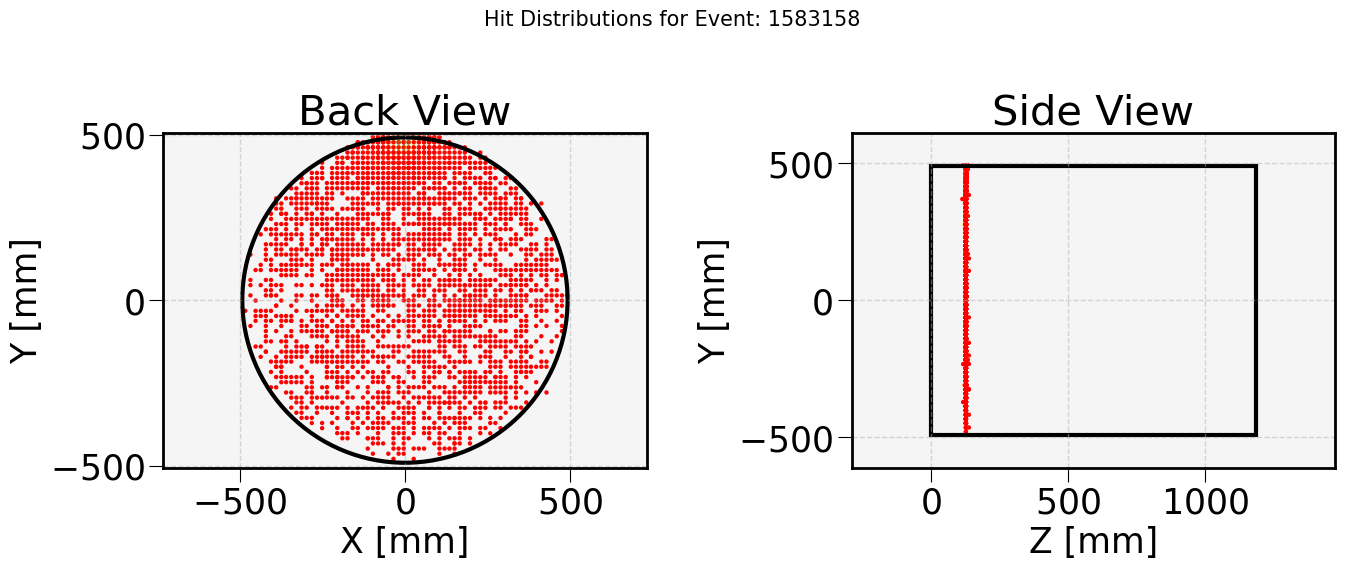

In [101]:
crudo.pt.event_display(df_final_soph, variable='E_hit_pe', event=np.random.choice(zero_s1_alpha_like))

### $nS1 = 1$

Here, the discriminator is the _corrected S1 energy_!

In [102]:
df_file.columns

Index(['event', 'npeak', 'E_peak_pe', 'X_bary', 'Y_bary', 'Z_bary', 'Z_min',
       'Z_max', 'R_max', 'E_evt_pe', 'n_cluster', 'time', 'reco_size', 'nS1',
       'nS2', 'main_S1e', 'main_S1e_corr', 'main_S1w', 'main_S1h', 'main_S1t',
       'main_S2e', 'main_S2w', 'main_S2h', 'main_S2t', 'main_S2q'],
      dtype='object')

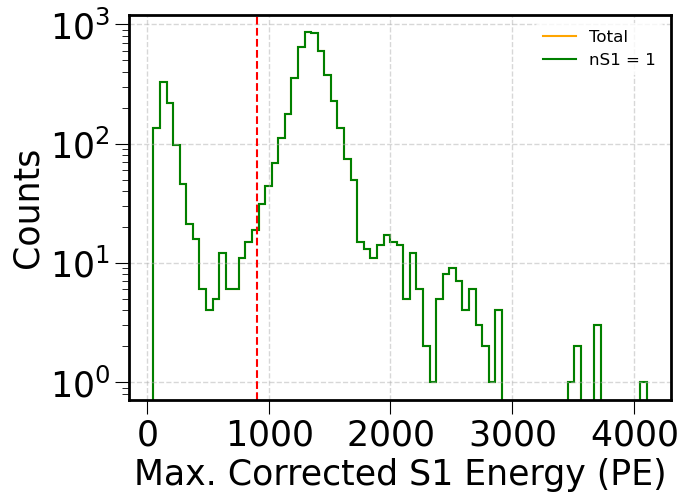

In [118]:
# Drop NaN values before creating histograms
main_S1e_corr_clean = df_file['main_S1e_corr'].dropna().unique()

# Histogram
total_counts, edges = np.histogram(main_S1e_corr_clean, bins=75)
one_s1_counts, _    = np.histogram(one_s1_events_df['main_S1e_corr'].unique(), bins=edges)

# Plotting
plt.figure(figsize=(7, 5))
plt.stairs(total_counts, edges, fill=False, ec='orange', lw=1.5, label='Total')
plt.stairs(one_s1_counts, edges, fill=False, ec='green', lw=1.5, label='nS1 = 1')

plt.axvline(x=S1_ENERGY_THRESHOLD, color='red', ls='--', lw=1.5)     # S1e_corr cut

# Styling
plt.xlabel('Max. Corrected S1 Energy (PE)')
plt.ylabel('Counts')
plt.yscale('log')
# plt.ticklabel_format(axis='x', style='sci', scilimits=(3, 3))
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

In [119]:
one_s1_elec_like  = one_s1_events_df.loc[one_s1_events_df['main_S1e_corr'] <= S1_ENERGY_THRESHOLD, 'event'].unique()
one_s1_alpha_like = one_s1_events_df.loc[one_s1_events_df['main_S1e_corr'] >  S1_ENERGY_THRESHOLD, 'event'].unique()
print(f"Number of electron-like events: {len(one_s1_elec_like)} ({len(one_s1_elec_like) / one_s1_events_df['event'].nunique() :.2%})")
print(f"Number of alpha-like events: {len(one_s1_alpha_like)} ({len(one_s1_alpha_like) / one_s1_events_df['event'].nunique() :.2%})")

Number of electron-like events: 944 (16.48%)
Number of alpha-like events: 4785 (83.52%)


Take a look to some event displays

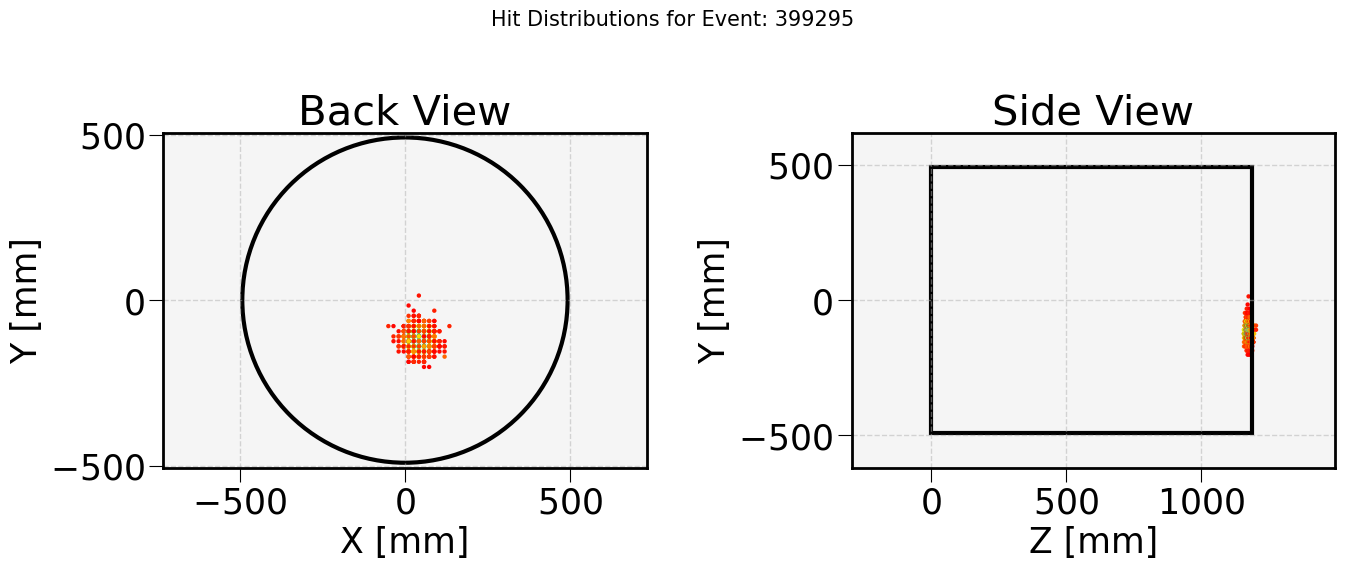

In [135]:
crudo.pt.event_display(df_final_soph, variable='E_hit_pe', event=np.random.choice(one_s1_elec_like))

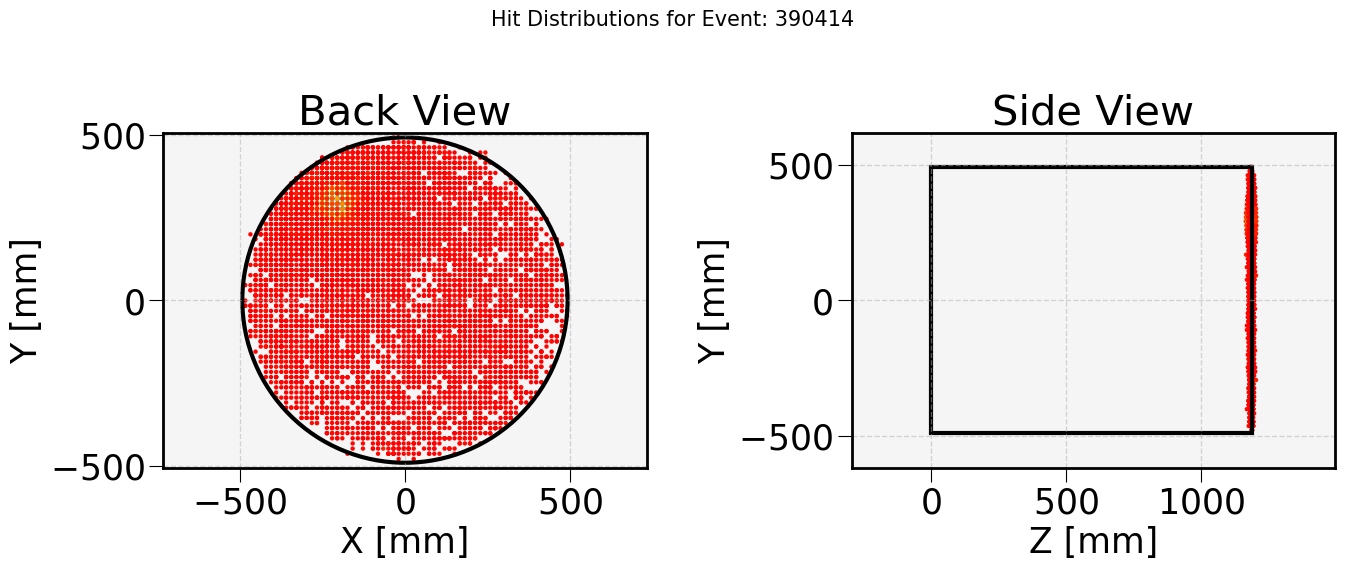

In [144]:
crudo.pt.event_display(df_final_soph, variable='E_hit_pe', event=np.random.choice(one_s1_alpha_like))

Mmm, how is the event size distribution for the alpha-like event (within $nS1=1$ category)?

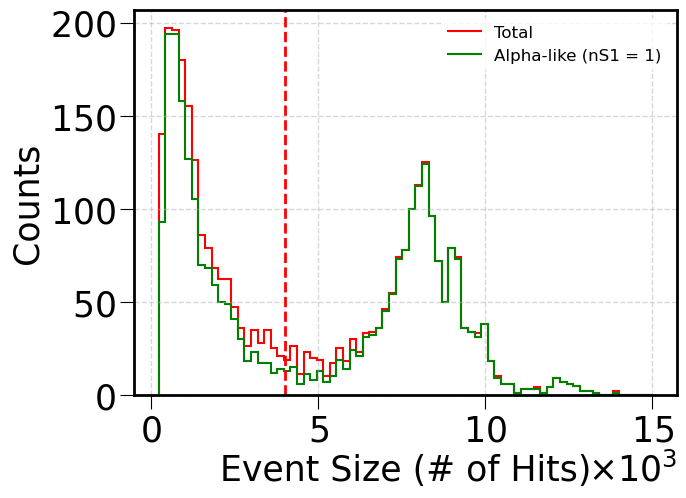

In [ ]:
# energy_based_one_s1_df = df_file[df_file['event'].isin(one_s1_alpha_like)].copy()

# # Histogram
# evt_size_counts, edges    = np.histogram(df_file['reco_size'].unique(), bins=75, range=(df_file['reco_size'].min(), 15e3))
# one_s1_evt_size_counts, _ = np.histogram(energy_based_one_s1_df['reco_size'].unique(), bins=edges)

# # Plotting
# plt.figure(figsize=(7, 5))
# plt.stairs(evt_size_counts, edges, fill=False, ec='red', lw=1.5, label='Total')
# plt.stairs(one_s1_evt_size_counts, edges, fill=False, ec='green', lw=1.5, label='Alpha-like (nS1 = 1)')

# plt.axvline(x=4e3, color='red', ls='--')     # Event size cut

# # Styling
# plt.xlabel('Event Size (# of Hits)')
# plt.ylabel('Counts')
# # plt.yscale('log')
# plt.ticklabel_format(axis='x', style='sci', scilimits=(3, 3))
# plt.legend(fontsize=12)
# plt.grid(True)
# plt.show()

We can make a discrimination based on size after using $S1$ energy, but we may lose some electrons with high-energy or still taking degraded alphas
<br>
It is time to leave it in this way.

### Are we tagging properly?

In [150]:
print('In this test, we have...')
test_elec_ids  = np.union1d(zero_s1_elec_like, one_s1_elec_like)
test_alpha_ids = np.union1d(zero_s1_alpha_like, one_s1_alpha_like)
print(f" - {len(test_elec_ids)} electron-like events")
print(f" - {len(test_alpha_ids)} alpha-like events")

# ----- Tests ----- #
overlaped_events = np.intersect1d(test_elec_ids, test_alpha_ids)
if len(overlaped_events) > 0:
    print(f"ERROR: There are {len(overlaped_events)} overlaped events!\n       Event IDs: {overlaped_events.tolist()}")

untagged_events = np.setdiff1d(df_file['event'].unique(), np.union1d(test_elec_ids, test_alpha_ids))
if len(untagged_events) > 0:
    print(f"ERROR: There are {len(untagged_events)} untagged events!\n         Event IDs: {untagged_events}")

In this test, we have...
 - 1569 electron-like events
 - 4983 alpha-like events


### Execution

In [151]:
tagged_df_file = crudo.dm.tag_particles(df_file, size_threshold=SIZE_THRESHOLD, s1_energy_threshold=S1_ENERGY_THRESHOLD)

In [153]:
# Split dataframes
electron_df = tagged_df_file[tagged_df_file['particle'] == 'electron'].copy()
alpha_df    = tagged_df_file[tagged_df_file['particle'] == 'alpha'].copy()
# Events ids
elec_ids  = electron_df.event.unique()
alpha_ids = alpha_df.event.unique()
print("After applying the tagging function, we have...")
print(f"  - {len(elec_ids)} electron-like events")
print(f"  - {len(alpha_ids)} alpha-like events")

# ----- Tests ----- #
if not np.array_equal(elec_ids, test_elec_ids):
    print("ERROR: Electron IDs do not match the test IDs!")
if not np.array_equal(alpha_ids, test_alpha_ids):
    print("ERROR: Alpha IDs do not match the test IDs!")

After applying the tagging function, we have...
  - 1569 electron-like events
  - 4983 alpha-like events


Let's see some event displays!

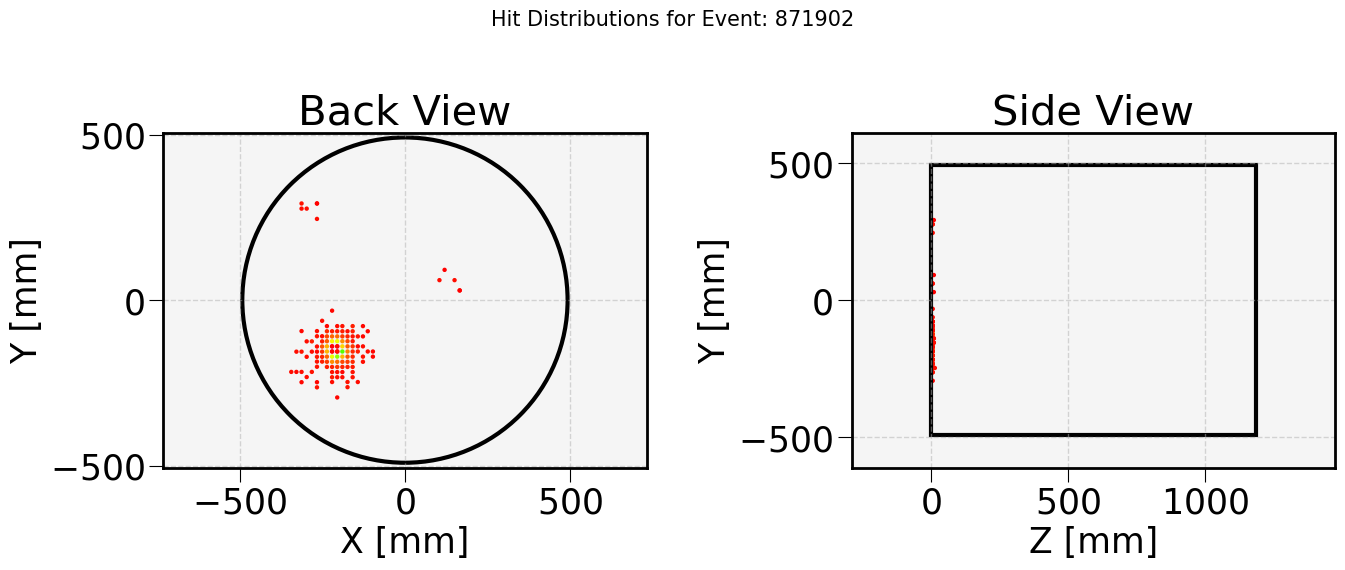

In [154]:
crudo.pt.event_display(df_final_soph, variable='E_hit_pe', event=np.random.choice(elec_ids))

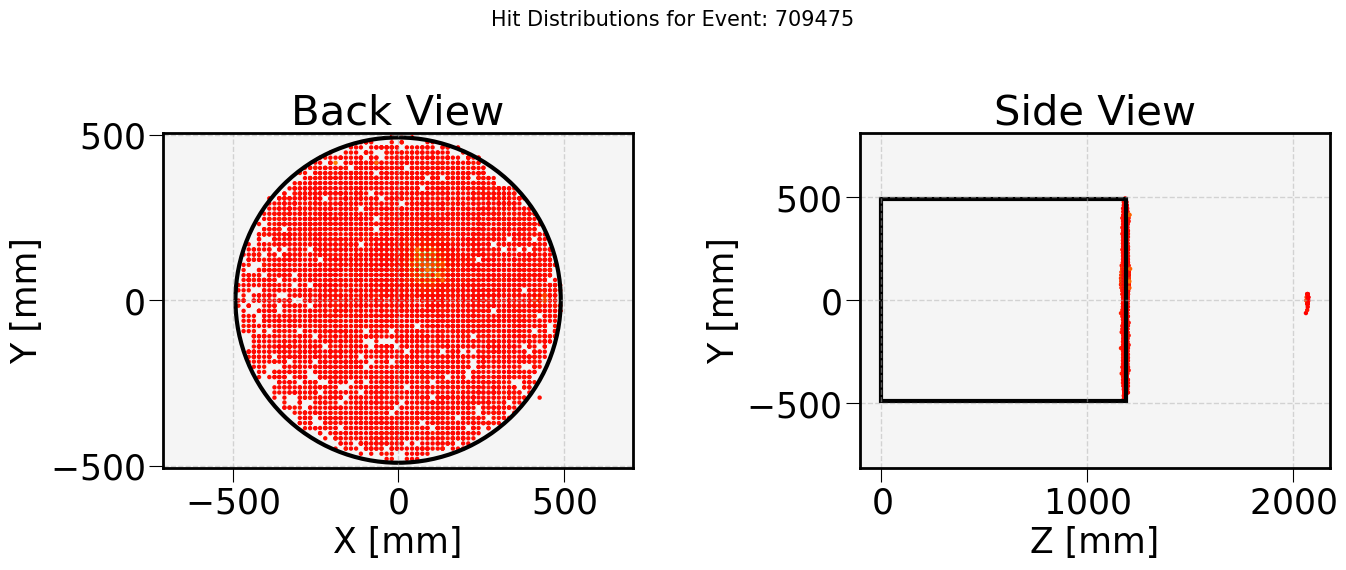

In [168]:
crudo.pt.event_display(df_final_soph, variable='E_hit_pe', event=np.random.choice(alpha_ids))

How is the energy spectrum?

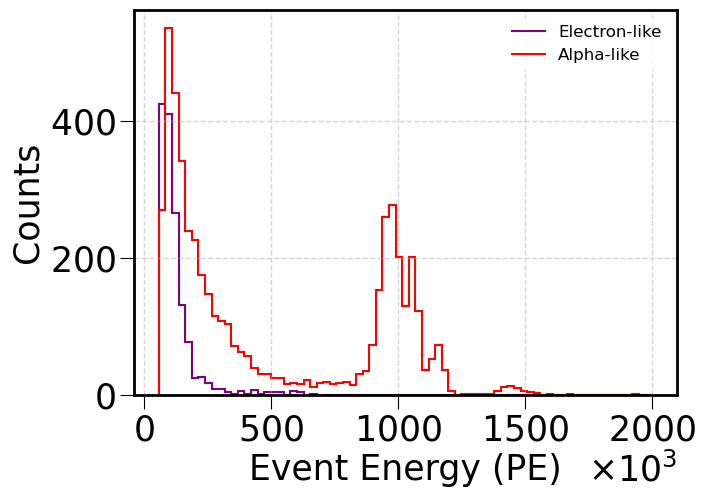

In [173]:
# Histogram
alpha_counts, edges = np.histogram(alpha_df['E_evt_pe'].unique(), bins=75, range=(alpha_df['E_evt_pe'].min(), 2000e3))
elec_counts, _      = np.histogram(electron_df['E_evt_pe'].unique(), bins=edges)

# Plotting
plt.figure(figsize=(7, 5))
plt.stairs(elec_counts, edges, fill=False, ec='purple', lw=1.5, label='Electron-like')
plt.stairs(alpha_counts, edges, fill=False, ec='red', lw=1.5, label='Alpha-like')

# plt.axvline(x=5.9, color='gray', ls='--', lw=2.0)     # 222Rn energy

# Styling
plt.xlabel('Event Energy (PE)')
plt.ylabel('Counts')
# plt.yscale('log')
plt.ticklabel_format(axis='x', style='sci', scilimits=(3, 3))
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

In [174]:
# --- Update Dataframe --- #
df_file = tagged_df_file.copy()

## By Detector Region

In [179]:
df_file

,event,npeak,E_peak_pe,X_bary,Y_bary,Z_bary,Z_min,Z_max,R_max,E_evt_pe,...,main_S1e_corr,main_S1w,main_S1h,main_S1t,main_S2e,main_S2w,main_S2h,main_S2t,main_S2q,particle
0,178,11,5.585313e+03,253.428421,252.614260,904.951362,46.319263,1868.260248,509.200880,3.310899e+05,...,NaN,NaN,NaN,NaN,264022.593750,90.000,48477.250000,1405482.250,60548.492188,alpha
1,178,31,3.203509e+05,253.428421,252.614260,904.951362,46.319263,1868.260248,509.200880,3.310899e+05,...,NaN,NaN,NaN,NaN,264022.593750,90.000,48477.250000,1405482.250,60548.492188,alpha
2,178,48,5.153635e+03,253.428421,252.614260,904.951362,46.319263,1868.260248,509.200880,3.310899e+05,...,NaN,NaN,NaN,NaN,264022.593750,90.000,48477.250000,1405482.250,60548.492188,alpha
3,596,34,9.497592e+05,214.449184,164.074252,1185.541926,1161.675646,1205.836166,499.423574,9.497592e+05,...,1380.192650,350.0,246.651306,47750.0,906339.750000,135.675,49674.238281,1418487.500,201896.500000,alpha
4,711,27,9.231329e+04,-53.236295,255.169671,1174.600854,1156.610530,1194.143853,370.276290,9.231329e+04,...,112.839575,700.0,20.737892,46075.0,94790.773438,370.175,3682.364502,1407489.625,66277.593750,electron
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7187,1790071,32,1.725046e+05,-229.014698,-320.010695,278.281627,243.819821,308.944265,504.123324,1.725046e+05,...,229.482413,600.0,25.064007,1082650.0,159537.343750,196.325,4075.479004,1411494.125,53259.515625,electron
7188,1790260,29,1.025993e+06,315.009025,-83.275197,1162.544361,1135.543455,1183.414826,509.721106,1.025993e+06,...,1395.891983,850.0,247.636429,73650.0,934126.750000,121.650,51649.296875,1417486.750,205730.296875,alpha
7189,1790324,36,4.928176e+05,-236.551410,277.649896,299.373106,286.700033,316.634656,537.571024,4.928176e+05,...,1458.815664,650.0,150.849915,1062875.0,430438.593750,123.150,47475.160156,1408490.500,105304.671875,alpha
7190,1790786,25,9.533714e+05,-121.297570,-133.106392,1184.429279,1163.551506,1207.965796,495.278181,9.533714e+05,...,1431.238275,700.0,246.000305,48400.0,949568.187500,117.500,53772.578125,1417484.250,215050.656250,alpha


In [180]:
df_final_soph

,event,time,npeak,X,Y,DT,Z,E_hit_pe,cluster,R_sq,X_w,Y_w,Z_w
0,596,1.759250e+09,34,227.675,199.275,1342.977625,1161.675646,11.867479,0,91546.43125,2701.928337,2364.891926,13786.161613
1,596,1.759250e+09,34,273.325,-48.025,1342.977625,1161.675646,10.176520,0,77012.95625,2781.497382,-488.727382,11821.815666
2,596,1.759250e+09,34,335.525,14.175,1346.798750,1164.980919,109.852327,0,112777.95625,36858.201957,1557.156733,127975.864629
3,596,1.759250e+09,34,-235.825,75.875,1350.692500,1168.349013,125.227046,0,61370.44625,-29531.668215,9501.602145,146308.895989
4,596,1.759250e+09,34,-19.125,-263.225,1350.692500,1168.349013,152.983362,0,69653.16625,-2925.806802,-40269.045511,178737.960135
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18440337,1790786,1.759302e+09,25,273.325,-1.375,1388.253875,1200.839602,64.606036,0,74708.44625,17658.444761,-88.833299,77581.486422
18440338,1790786,1.759302e+09,25,-158.075,-186.475,1392.319625,1204.356476,762.740569,0,59760.63125,-120570.215463,-142232.047625,918611.543633
18440339,1790786,1.759302e+09,25,-126.975,-186.475,1392.319625,1204.356476,709.998804,0,50895.57625,-90152.098104,-132397.026926,855091.656963
18440340,1790786,1.759302e+09,25,-19.125,-309.875,1392.319625,1204.356476,685.865864,0,96388.28125,-13117.184646,-212532.684560,826026.994535


### Execution

In [181]:
region_tagged_df = crudo.dm.tag_event_by_detector_region(df_file, z_cut_low=Z_LOW, z_cut_high=Z_UP, r_cut_high=R_UP)

Are these tags ok?

In [182]:
region_tagged_df

,event,npeak,E_peak_pe,X_bary,Y_bary,Z_bary,Z_min,Z_max,R_max,E_evt_pe,...,main_S1w,main_S1h,main_S1t,main_S2e,main_S2w,main_S2h,main_S2t,main_S2q,particle,region
0,178,11,5.585313e+03,253.428421,252.614260,904.951362,46.319263,1868.260248,509.200880,3.310899e+05,...,NaN,NaN,NaN,264022.593750,90.000,48477.250000,1405482.250,60548.492188,alpha,anode
1,178,31,3.203509e+05,253.428421,252.614260,904.951362,46.319263,1868.260248,509.200880,3.310899e+05,...,NaN,NaN,NaN,264022.593750,90.000,48477.250000,1405482.250,60548.492188,alpha,anode
2,178,48,5.153635e+03,253.428421,252.614260,904.951362,46.319263,1868.260248,509.200880,3.310899e+05,...,NaN,NaN,NaN,264022.593750,90.000,48477.250000,1405482.250,60548.492188,alpha,anode
3,596,34,9.497592e+05,214.449184,164.074252,1185.541926,1161.675646,1205.836166,499.423574,9.497592e+05,...,350.0,246.651306,47750.0,906339.750000,135.675,49674.238281,1418487.500,201896.500000,alpha,cathode
4,711,27,9.231329e+04,-53.236295,255.169671,1174.600854,1156.610530,1194.143853,370.276290,9.231329e+04,...,700.0,20.737892,46075.0,94790.773438,370.175,3682.364502,1407489.625,66277.593750,electron,cathode
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7187,1790071,32,1.725046e+05,-229.014698,-320.010695,278.281627,243.819821,308.944265,504.123324,1.725046e+05,...,600.0,25.064007,1082650.0,159537.343750,196.325,4075.479004,1411494.125,53259.515625,electron,tube
7188,1790260,29,1.025993e+06,315.009025,-83.275197,1162.544361,1135.543455,1183.414826,509.721106,1.025993e+06,...,850.0,247.636429,73650.0,934126.750000,121.650,51649.296875,1417486.750,205730.296875,alpha,cathode
7189,1790324,36,4.928176e+05,-236.551410,277.649896,299.373106,286.700033,316.634656,537.571024,4.928176e+05,...,650.0,150.849915,1062875.0,430438.593750,123.150,47475.160156,1408490.500,105304.671875,alpha,tube
7190,1790786,25,9.533714e+05,-121.297570,-133.106392,1184.429279,1163.551506,1207.965796,495.278181,9.533714e+05,...,700.0,246.000305,48400.0,949568.187500,117.500,53772.578125,1417484.250,215050.656250,alpha,cathode


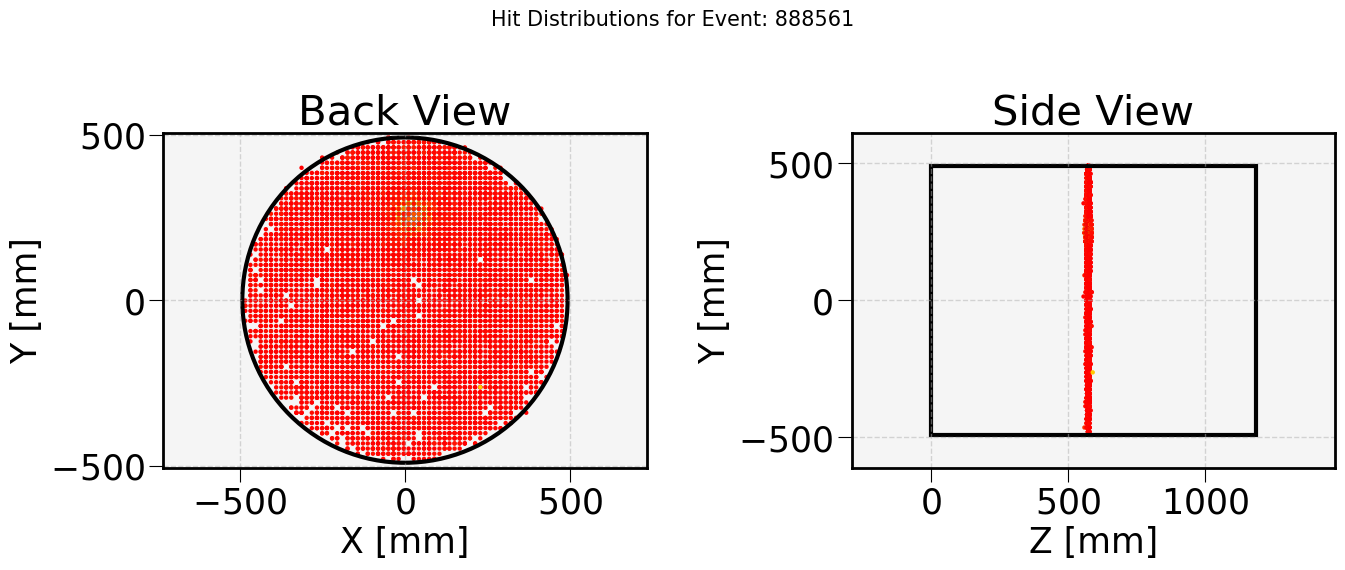

In [220]:
crudo.pt.event_display(df_final_soph, variable='E_hit_pe', event=np.random.choice(region_tagged_df.loc[region_tagged_df['region'] == 'tube', 'event'].unique()))

And also, let's find the event counters

In [221]:
detector_region_counts = df_file.groupby(['particle', 'region'])['event'].nunique()
detector_region_counts

particle  region  
alpha     anode        234
          cathode     1445
          fiducial       1
          tube        3303
electron  anode        636
          cathode      413
          fiducial     143
          tube         377
Name: event, dtype: int64

In [223]:
test_df = df_file[(df_file['particle'] == 'electron') & (df_file['region'] == 'cathode')].copy()
print(f"By using a dataframe: {test_df.event.nunique()}")
print(f"By using a series: {detector_region_counts.get(('electron', 'cathode'), 0)}")

# Verifiy if there are columns with uint64 type
uint64_columns = df_file.select_dtypes(include=['uint64']).columns
print("\nColumns with uint64 type:", uint64_columns)

By using a dataframe: 413
By using a series: 413

Columns with uint64 type: Index(['npeak'], dtype='object')


# Trigger02 Window

We convert the event energy to MeV and apply the energy window cut.

In [224]:
df_file = crudo.ef.energy_pe_to_mev(df_file, slope=M_HE_SCALE, intercept=B_HE_SCALE, input_column='E_evt_pe', output_column='E_evt_mev')
df_file

,event,npeak,E_peak_pe,X_bary,Y_bary,Z_bary,Z_min,Z_max,R_max,E_evt_pe,...,main_S1h,main_S1t,main_S2e,main_S2w,main_S2h,main_S2t,main_S2q,particle,region,E_evt_mev
0,178,11,5.585313e+03,253.428421,252.614260,904.951362,46.319263,1868.260248,509.200880,3.310899e+05,...,NaN,NaN,264022.593750,90.000,48477.250000,1405482.250,60548.492188,alpha,anode,1.598631
1,178,31,3.203509e+05,253.428421,252.614260,904.951362,46.319263,1868.260248,509.200880,3.310899e+05,...,NaN,NaN,264022.593750,90.000,48477.250000,1405482.250,60548.492188,alpha,anode,1.598631
2,178,48,5.153635e+03,253.428421,252.614260,904.951362,46.319263,1868.260248,509.200880,3.310899e+05,...,NaN,NaN,264022.593750,90.000,48477.250000,1405482.250,60548.492188,alpha,anode,1.598631
3,596,34,9.497592e+05,214.449184,164.074252,1185.541926,1161.675646,1205.836166,499.423574,9.497592e+05,...,246.651306,47750.0,906339.750000,135.675,49674.238281,1418487.500,201896.500000,alpha,cathode,4.568244
4,711,27,9.231329e+04,-53.236295,255.169671,1174.600854,1156.610530,1194.143853,370.276290,9.231329e+04,...,20.737892,46075.0,94790.773438,370.175,3682.364502,1407489.625,66277.593750,electron,cathode,0.452504
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7187,1790071,32,1.725046e+05,-229.014698,-320.010695,278.281627,243.819821,308.944265,504.123324,1.725046e+05,...,25.064007,1082650.0,159537.343750,196.325,4075.479004,1411494.125,53259.515625,electron,tube,0.837422
7188,1790260,29,1.025993e+06,315.009025,-83.275197,1162.544361,1135.543455,1183.414826,509.721106,1.025993e+06,...,247.636429,73650.0,934126.750000,121.650,51649.296875,1417486.750,205730.296875,alpha,cathode,4.934166
7189,1790324,36,4.928176e+05,-236.551410,277.649896,299.373106,286.700033,316.634656,537.571024,4.928176e+05,...,150.849915,1062875.0,430438.593750,123.150,47475.160156,1408490.500,105304.671875,alpha,tube,2.374925
7190,1790786,25,9.533714e+05,-121.297570,-133.106392,1184.429279,1163.551506,1207.965796,495.278181,9.533714e+05,...,246.000305,48400.0,949568.187500,117.500,53772.578125,1417484.250,215050.656250,alpha,cathode,4.585583


In [226]:
# Trigger 2 efficiency cut
trg2_mask = (df_file['E_evt_mev'] >= TRG2_THRESHOLD)
trg2_final_df, trg2_soph_df = crudo.dm.apply_cut_and_update(df_file, df_final_soph, cut_mask=trg2_mask, df_for_mask=df_file)

Let's see the energy spectrum

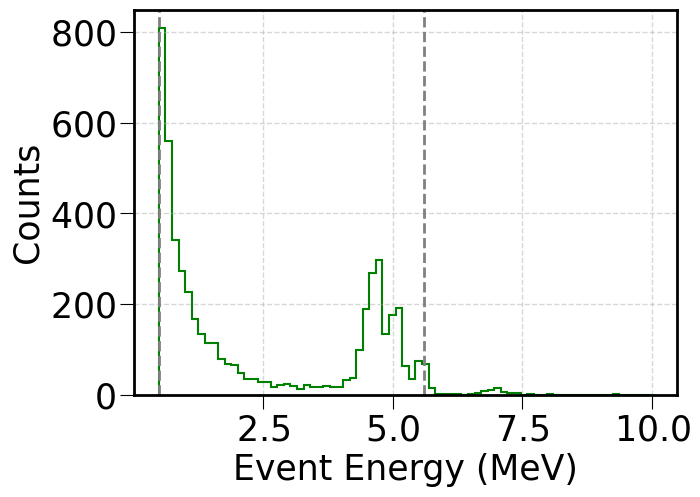

In [227]:
# Histogram
E_counts, edges = np.histogram(trg2_final_df['E_evt_mev'].unique(), bins=75, range=(trg2_final_df['E_evt_mev'].min(), 10))      # There are values up to ~20 MeV 

# Plotting
plt.figure(figsize=(7, 5))
plt.stairs(E_counts, edges, fill=False, ec='green', lw=1.5)

plt.axvline(x=0.5, color='gray', ls='--')     # Trigger02 threshold
plt.axvline(x=5.6, color='gray', ls='--')     # 222Rn energy

# Styling
plt.xlabel('Event Energy (MeV)')
plt.ylabel('Counts')
# plt.yscale('log')
plt.grid(True)
plt.show()

In [228]:
# --- Update Dataframe --- #
df_file = trg2_final_df.copy()
df_final_soph = trg2_soph_df.copy()

print(f"After Trigger 2 efficiency cut: {df_file['event'].nunique()} events.")

After Trigger 2 efficiency cut: 5072 events.
